In [1]:
from first_part import *
import anndata as ad
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests 
import seaborn as sns
from sklearn.model_selection import LeaveOneOut, RepeatedKFold, RepeatedStratifiedKFold, StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import mannwhitneyu, spearmanr, pearsonr
import scanpy as sc
import matplotlib
# from lightgbm import LGBMClassifier
from sklearn.dummy import DummyClassifier
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from joblib import Parallel, delayed, parallel_backend
from sklearn.feature_selection import VarianceThreshold 
import warnings
import os
warnings.filterwarnings("ignore")
import numpy as np
np.seterr(divide='ignore', invalid='ignore')

from utils import *
import os
atac_input_file_name = "../../Cellformer/cellformer_PD/adata_deconvolution_PD_2024_trained_all_filtered_Jan6_lognorm_0.2.h5ad"
outdir = "./outdir/"
if not os.path.exists(outdir):
    os.mkdir(outdir)

/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packag

In [2]:
import scipy
scipy.__version__

'1.11.4'

In [3]:
adata = sc.read_h5ad(atac_input_file_name)
adata = prepareData(adata)
adata

AnnData object with n_obs × n_vars = 2358 × 42352
    obs: 'celltype', 'replicate', 'brain_region', 'condition', 'Sex', 'batch', 'PatientID', 'Unnamed: 0', 'Sample_id', 'Name', 'OldName', 'NewName', 'HarmonizedName', 'Bam', 'Contrast', 'Type', 'Group', 'Region', 'RegionMod', 'PatientIDMod', 'TypeMod', 'Cohort', 'TissueCenter', 'TypeGroup', 'xxx.TechRep', 'Batch', 'xxx.Sample', 'xxx.Library', 'xxx.BioRep', 'xxx.TechRep.1', 'Pool', 'xxx.race', 'Gender', 'age at death', 'PMI', 'Mutation', 'MutationType', 'xxx.last_mmse_test_score', 'ApoE', 'xxx.last_mmse_test_date', 'xxx.motor_updrs_score_on', 'xxx.motor_updrs_score_off', 'xxx.motor_updrs_score_months_prior_to_death', 'xxx.Control', 'xxx.AD', 'xxx.PD', 'xxx.DLB', 'xxx.VAD', 'xxx.PSP', 'xxx.HS', 'xxx.DLDH', 'xxx.MND', 'xxx.CBD', 'xxx.PICKS', 'xxx.HD', 'xxx.MSA', 'xxx.ARG', 'xxx.CWMR', 'xxx.dementia_nos', 'xxx.MS', 'xxx.CAA', 'xxx.MCI', 'xxx.LBS', 'xxx.BRAIN_ABNORMAL', 'xxx.ACUTE_INFARCTS', 'xxx.PlaqueF', 'xxx.PlaqueT', 'xxx.PlaqueP', 'xxx.

In [4]:
adata.obs.condition.unique()
adata.obs["condition"] = adata.obs["condition"].replace({"GBA1-PD+":"GBA1", "LRRK2-PD+":"LRRK2"})
adata.obs["condition"].unique()

array(['CTRL', 'SPOR', 'GBA1', 'LRRK2'], dtype=object)

In [5]:
def train_inner(X, y, group, inner_cv, nb, algo, br, ct, comp,
               variance_thres=0):
    pred_i = []
    tt_i= []
    pred_c = []
    pred_dum = []
    tmp = pd.DataFrame(columns=["comp","brain_region", "ct", "n_features", "algo", "auc", "auprc","f1", "auc_dum"])
    for i2, (train_inner, test_inner) in enumerate(inner_cv.split(X, y, groups=group)):
        X_train_inner, X_test_inner = X[train_inner,:], X[test_inner,:]
        y_train_inner, y_test_inner = y[train_inner], y[test_inner]
        if len(set(y_train_inner))>1:
            clf = models[algo]
            pipe = Pipeline([#("scale", StandardScaler()),
                                 ("filter",VarianceThreshold(threshold=variance_thres)),
                                                    # ("red", PCA(n_components=len(y_train_inner))),
                                ("select", SelectKBest(f_classif,k=nb)),
                                ("model", clf)
                            ])
    
            pipe.fit(np.array(X_train_inner), np.array(y_train_inner))
            y_pred = np.array(pipe.predict_proba(np.array(X_test_inner))[:, 1])
            y_pred_c = np.array(pipe.predict(np.array(X_test_inner)))
            pred_i.append(y_pred)
            tt_i.append(y_test_inner)
            pred_c.append(y_pred_c)
            pipe = Pipeline([#("scale", StandardScaler()),
                                  ("filter",VarianceThreshold(threshold=variance_thres)),
                                                    # ("red", PCA(n_components=len(y_train_inner))),
                                                      ("select", SelectKBest(f_classif,k=nb)),
                                                    ("model", DummyClassifier())
                                                    ])
            pipe.fit(np.array(X_train_inner), np.array(y_train_inner))
            y_pred_dummy = np.array(pipe.predict_proba(np.array(X_test_inner))[:, 1])
            pred_dum.append(y_pred_dummy)                
    y_preds = np.hstack(pred_i)
    y_tests = np.hstack(tt_i)#.astype(int)
    y_pred_du = np.hstack(pred_dum)
    auc = roc_auc_score(y_tests, y_preds)#, average="weighted")
    auprc = average_precision_score(y_tests, y_preds)#, average="weighted")
    y_preds_c = np.hstack(pred_c)
    auc_dum = roc_auc_score(y_tests, y_pred_du)#, average="weighted")
    f1 = f1_score(y_tests, y_preds_c)#, average="weighted")
    tmp.loc[0,:] = [comp,br,ct,nb, algo,auc,auprc,f1, auc_dum]
    return tmp  
    
def train_outer(X,y,group,n_out_splits,ri, inner_cv,comp, br, ct, feat_, model_list,
               variance_thres=0):
    outer_cv_results = {key: [] for key in ["comp","brain_region", "ct", "outer_split","ri", "n_features", "algo",
                                            "F1","AUROC", "AUPRC","F1 random","AUROC random", "AUPRC random"]}

    rng = np.random.default_rng(ri)
    rints = rng.integers(low=0, high=1000, size=1)
    outer_cv = StratifiedGroupKFold(n_splits=n_out_splits, shuffle=True,  random_state=ri)
    tot_in = []
    for i0, (train_index, test_index) in enumerate(outer_cv.split(X,y,groups=group)):
        X_train, X_test = X[train_index, :], X[test_index, :]
        y_train, y_test = y[train_index], y[test_index]
        patient_inner = np.asarray(group)[train_index]
                            # print(y_test)
        test_0, test_1 = len(y_test[y_test==0]), len(y_test[y_test==1])
        print('>Test: 0=%d, 1=%d' % (test_0, test_1))
                            # name = algo+"_"+covar+br+ct+"_"+method+"_"+str(nb)
        if (len(set(y_test))==2)&(len(set(y_train))==2):
   
            out = Parallel(n_jobs=40, verbose=0)(
                    delayed(train_inner)(X_train, y_train, patient_inner, 
                    inner_cv, nb, algo, br, ct, comp) for nb in feat_ for k,algo in enumerate(model_list))#
            inner_cv_results = pd.concat(out)
            inner_cv_results["outer_split"] = i0
            inner_cv_results["ri"] = ri
            best_ = inner_cv_results[inner_cv_results.f1==inner_cv_results.f1.max()]
            best_ = best_.sort_values("auprc",ascending=False)
            # print(best_)
                                # best_ = best_[best_.auc==best_.auc.max()]
            b_nb_feat, b_mod = best_["n_features"].values[0], best_["algo"].values[0]
            pipe = Pipeline([#("scale", StandardScaler()),
                            ("filter",VarianceThreshold(threshold=variance_thres)),
                            ("select", SelectKBest(f_classif,k=b_nb_feat)),
                            ("model", models[b_mod])
                            ])
                                
            pipe.fit(np.array(X_train), np.array(y_train))
            y_pred = np.array(pipe.predict_proba(np.array(X_test))[:, 1])
            y_pred_c = np.array(pipe.predict(np.array(X_test)))

            pipe = Pipeline([#("scale", StandardScaler()),
                                                ("filter",VarianceThreshold(threshold=variance_thres)),
                                              # ("red", PCA(n_components=len(train_index))),
                                                       ("select", SelectKBest(f_classif,k=b_nb_feat)),
                                                    ("model", DummyClassifier())
                                                    ])
            pipe.fit(np.array(X_train), np.array(y_train))
            y_pred_dummy = np.array(pipe.predict_proba(np.array(X_test))[:, 1])
            y_pred_dummy_c = np.array(pipe.predict(np.array(X_test)))
            outer_cv_results["comp"].append(comp)
            outer_cv_results["outer_split"].append(i0)
            outer_cv_results["ri"].append(ri)
        
            outer_cv_results["n_features"].append(b_nb_feat)
            outer_cv_results["algo"].append(b_mod)
            outer_cv_results["brain_region"].append(br)
            outer_cv_results["ct"].append(ct)
            outer_cv_results["AUROC"].append(roc_auc_score(y_test, y_pred))#, average="weighted"))
            outer_cv_results["AUPRC"].append(average_precision_score(y_test, y_pred))#, average="weighted"))
            outer_cv_results["F1"].append(f1_score(y_test, y_pred_c))#, average="weighted"))
            outer_cv_results["AUROC random"].append(roc_auc_score(y_test, y_pred_dummy))#, average="weighted"))
            outer_cv_results["AUPRC random"].append(average_precision_score(y_test, y_pred_dummy))#, average="weighted"))
            outer_cv_results["F1 random"].append(f1_score(y_test, y_pred_dummy_c))#, average="weighted"))
    out_selection = pd.DataFrame(outer_cv_results)
    return out_selection
                   
def train_final(X,y,group,ri, nb, mod,
                n_out_splits,
               ct,br, comp, X_ctrl=None, X_lrrk2=None,
               variance_thres=0):
    l_y_pred = []
    l_y_pred_c = []
    l_y_test = []
    l_y_pred_spor = []
    l_y_pred_gba1 = []
    pred_dum = []
    pred_dum_c = []
    ans_matrix = []
    preds_mat = []
    tests_mat = []
    res = pd.DataFrame( columns=['model','celltype','brain_region',"nb_features",'comp','AUROC',"AUPRC","pvalue", "F1", "AUROC random", "AUPRC random", "F1 random"])
    i = 0
    rng = np.random.default_rng(ri)
    rints = rng.integers(low=0, high=1000, size=1)
    outer_cv = StratifiedGroupKFold(n_splits=n_out_splits, shuffle=True,  random_state=rints[0])
    y_pred_ctrl = []
    y_pred_lrrk2 = []
    nb_ = len(y)
    rows = len(X)
    for i1, (train_index, test_index) in enumerate(outer_cv.split(X,y,groups=group)):
        
        X_train, X_test = X[train_index, :], X[test_index, :]
        y_train, y_test = y[train_index], y[test_index]
                            # patient_inner = pat[train_index]
        if (len(set(y_train))>1) & (len(set(y_test))>1):
            pipe = Pipeline([#("scale", StandardScaler()),
            
                             ("filter",VarianceThreshold(threshold=variance_thres)),
                                                    # ("red", PCA(n_components=len(train_index))),
                                                       ("select", SelectKBest(f_classif,k=nb)),
                                                    ("model", models[mod])
                                                    ])
            pipe.fit(np.array(X_train), np.array(y_train))
    
            y_pred = np.array(pipe.predict_proba(np.array(X_test))[:, 1])
            y_pred_c = np.array(pipe.predict(np.array(X_test)))
            # tmp = np.empty((nb_))
            # tmp[test_index] = y_pred
            # # df_results.loc[len(df_results),:] = ["pred",i1] + tmp.tolist()
            # tmp = np.empty((nb_))
            # tmp[test_index] = y_test
            # df_results.loc[len(df_results),:] = ["true",i1] + tmp.tolist()
            if X_ctrl is not None:
                y_pred_ctrl = np.array(pipe.predict_proba(np.array(X_ctrl))[:, 1])
                # df_results_ctrl.loc[len(df_results_ctrl),:] = ["pred_ctrl",i1] + y_pred_ctrl.tolist()
            if X_lrrk2 is not None:
                y_pred_lrrk2.append(np.array(pipe.predict_proba(np.array(X_lrrk2))[:, 1]))
                # df_results_lrrk2.loc[len(df_results_lrrk2),:] = ["pred_lrrk2",i1] + y_pred_lrrk2.tolist()
            l_y_pred.append(y_pred)
            l_y_test.append(y_test)
            l_y_pred_spor.append(np.mean(y_pred[y_test==0]))
            l_y_pred_gba1.append(np.mean(y_pred[y_test==1]))
            l_y_pred_c.append(y_pred_c)

            y_error = np.abs(y_pred - np.asarray(y_test))
            ans_list = [None] * rows
            p_list = [None] * rows
            t_list = [None] * rows
            start = 0
            for j in test_index:
                ans_list[j] = y_error[start]
                p_list[j] = y_pred[start]
                t_list[j] = y_test[start]
                start += 1
                                        
            ans_matrix.append(ans_list)
            preds_mat.append(p_list)
            tests_mat.append(t_list)

            
            pipe = Pipeline([#("scale", StandardScaler()),
                             ("filter",VarianceThreshold(threshold=variance_thres)),

                                                    # ("red", PCA(n_components=len(train_index))),
                                                       ("select", SelectKBest(f_classif,k=nb)),
                                                    ("model", DummyClassifier())
                                                    ])
            pipe.fit(np.array(X_train), np.array(y_train))
            y_pred_dummy = np.array(pipe.predict_proba(np.array(X_test))[:, 1])
            pred_dum.append(y_pred_dummy)  
            y_pred_dummy = np.array(pipe.predict(np.array(X_test)))
            pred_dum_c.append(y_pred_dummy)  
    y_preds = np.hstack(l_y_pred)
    y_preds_c = np.hstack(l_y_pred_c)
    y_tests = np.hstack(l_y_test)
    y_pred_du = np.hstack(pred_dum)
    y_pred_du_c = np.hstack(pred_dum_c)
    auc = roc_auc_score(y_tests, y_preds)#, average="weighted")
    auprc = average_precision_score(y_tests, y_preds)#, average="weighted")#np.mean(l_auroc)
    f1 = f1_score(y_tests, y_preds_c)#, average="weighted")
    pv = mannwhitneyu(y_preds[y_tests==0], y_preds[y_tests==1]).pvalue
    auc_dum = roc_auc_score(y_tests, y_pred_du)#, average="weighted")
    auprc_dum = average_precision_score(y_tests, y_pred_du)#, average="weighted")
    f1_dum = average_precision_score(y_tests, y_pred_du_c)#, average="weighted")

    res.loc[0,:] = [l_mod, ct,br,l_nb_feat,comp,auc, auprc,pv,f1,auc_dum, auprc_dum, f1_dum]

    ans = np.array(ans_matrix)
    ans = np.transpose(ans)
    df_ans = pd.DataFrame(ans)

    ans = np.array(preds_mat)
    ans = np.transpose(ans)
    df_preds = pd.DataFrame(ans)
                    # print(df_preds)

    ans = np.array(tests_mat)
    ans = np.transpose(ans)
    df_tests = pd.DataFrame(ans)
    # y_lrrk2 = np.mean(np.vstack(y_pred_lrrk2),axis=0)
    #                 # print(y_lrrk2.shape)
    # # y_ctrl = np.mean(np.vstack(y_pred_ctrl),axis=0)
    # y_spor = np.hstack(l_y_pred_spor)
    # y_gba1 = np.hstack(l_y_pred_gba1)
    return res, df_ans, df_preds, df_tests, y_pred_lrrk2#, l_y_pred_spor, l_y_pred_gba1

models = {
        'EN': LogisticRegression(penalty='elasticnet', l1_ratio=0.5, fit_intercept=False, solver='saga', 
                                                         max_iter=10000, random_state=1), #'EN': customLogisticRegressionCV(cv=5, l1_ratios=[0, 0.25, 0.5, 0.75, 1], fit_intercept=False),
        'LASSO': LogisticRegression(penalty='l1', fit_intercept=False, solver='saga', max_iter=10000, random_state=1), #customLogisticRegressionCV(cv=5, l1_ratios=[1], fit_intercept=False), #
        'Ridge': LogisticRegression(penalty='l2', fit_intercept=False, random_state=1), #customLogisticRegressionCV(cv=5, l1_ratios=[0], fit_intercept=False), #
        'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=1),
        'KNN': KNeighborsClassifier(n_jobs=-1),
        'SVM': SVC(probability=True, random_state=1),  #rbf for AD, linear for LBD
        'XGBoost': XGBClassifier(n_jobs=-1, random_state=1,  device="cpu"),
                                # "LGBM":LGBMClassifier(random_state=1)
                            }



In [76]:
warnings.filterwarnings("ignore")
model_list = ['LASSO', 'Ridge', 'EN','Random Forest', 'SVM', "XGBoost"]#,"LGBM" ]
celltypes  = list(adata.obs.celltype.unique())
brain_regions  = ["HIPP",'CAUD', 'MDFG', 'PTMN', 'SUNI', "SMTG"]#list(adata.obs.brain_region.unique())
inner_cv = StratifiedGroupKFold(n_splits=5,shuffle=True, random_state=1)
nb_boostrap = 5
n_out_splits = 10
feat_ = [50, 100, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
outer_cv_results = {key: [] for key in ["comp","brain_region", "ct", "outer_split","ri",
                                        "n_features", "algo", "F1","AUROC", "AUPRC","F1 random",
                                        "AUROC random", "AUPRC random"]}
res = []
res_inn = []
dico = {}
for comp in ["SPOR$GBA1"]: #,"SPOR$All", "GBA1$All"]:#  #, "CTRL$All"]: #comparisons:
    cond0,cond1 = comp.split('$')
    namef = "./multivariate_nested_cv.pickle"
    # if not os.path.exists(namef):
    if True:
        print(namef)
        for br in brain_regions:
            for ct in celltypes:
                if ct!="bulk":
                    print(br)
                    print(ct)
                    print(comp)
                    if cond1 !="All":
                        condition_filtering = ((adata.obs.condition.isin([cond0,cond1]))
                                           & (adata.obs.celltype.isin([ct]))
                                           & (adata.obs.brain_region.isin([br])))
                        condition_filtering2 = ((adata.obs.celltype.isin([ct]))
                                           & (adata.obs.brain_region.isin([br])))
                        dict_cond = {cond0:0,cond1:1}

                    else:
                        condition_filtering = ((adata.obs.celltype.isin([ct]))
                                           & (adata.obs.brain_region.isin([br]))
                                              )
                        conds = adata.obs.condition.unique().tolist()
                        dict_cond = {it:0 if it ==cond0 else 1 for it in conds}
                    adata_filtered = adata[condition_filtering,:]
                    X_ctrl=None
                    X_lrrk2=None
                    adata2 = adata[condition_filtering2,:]
                    adata2 =  adata2[:, adata_filtered.X.sum(0)!=0]
                    X_lrrk2 = adata2[adata2.obs.condition=="LRRK2"].X
                    adata_filtered =  adata_filtered[:, adata_filtered.X.sum(0)!=0]
                    
                    patients,X,y = (adata_filtered.obs[["PatientID","condition"]].reset_index(drop=True),
                                    adata_filtered.X, adata_filtered.obs["condition"].map(dict_cond).values) 
                            
                    group = adata_filtered.obs.PatientID.tolist()
                    outer_ = []
                    for ri in tqdm(range(nb_boostrap)):
                        tmp =  train_outer(X,y,group, n_out_splits,ri, inner_cv,
                                    comp, br, ct, feat_, model_list)
                        outer_.append(tmp)
                    # outer_ = Parallel(n_jobs=1, verbose=0, pre_dispatch='1.5*n_jobs')(
                    #                 delayed(train_outer)(X,y,group, n_out_splits,ri, inner_cv,
                    #                 comp, br, ct, feat_, model_list) for ri in tqdm(range(nb_boostrap)))
                                      
                    out_selection = pd.concat(outer_)
                    
                    # res_out.append(out_selection)
                    out_selection["-nb_feat"] = -out_selection["n_features"]
                    res_inn.append(out_selection)
                    out = out_selection[(out_selection.comp == comp)
                                                  &(out_selection.brain_region == br)
                                                  &(out_selection.ct ==ct)
                                                  ].sort_values(["F1", "-nb_feat"]).iloc[-1,:]
                    
              
                    l_nb_feat, l_mod = out.loc["n_features"], out.loc["algo"]
                    
                    print(l_mod)
                    print(l_nb_feat)
                    outal = Parallel(n_jobs=30, verbose=100)(
                                        delayed(train_final)(X,y,group,ri,  int(l_nb_feat), l_mod,
                                                n_out_splits,
                                        ct,br, comp, X_ctrl, X_lrrk2) for ri in tqdm(range(nb_boostrap)))
                    # print(out)
                    out = [it[0] for it in outal]
                    df_ans = pd.concat([it[1] for it in outal], axis=1)
                    df_preds = pd.concat([it[2] for it in outal], axis=1)
                    df_tests = pd.concat([it[3] for it in outal], axis=1)
                    y_pred_lrrk2 = []
                    y_pred_spor = []
                    y_pred_gba1 = []
                    for it in outal:
                        y_pred_lrrk2 += list(it[4])
                    
                    dico_ = {}
                    y_lrrk2 = np.mean(np.vstack(y_pred_lrrk2),axis=0)

                    dico_["y_lrrk2"] = y_lrrk2
                    dico_["y_error"] = df_ans
                    dico_["tests"] = df_tests
                    dico_["preds"] = df_preds
                    dico_["meta"] = adata_filtered.obs

                    dico["%s_%s"%(br,ct)] = dico_

                    rest = pd.concat(out)
                    mean_auc = np.mean(rest["AUROC"].values)
                    std_auc = np.std(rest["AUROC"].values)
                    mean_au = np.mean(rest["AUPRC"].values)
                    mean_f1 = np.mean(rest["F1"].values)
                    mea_du = np.mean(rest["AUROC random"].values)
                    print(f"{ct}, {br}, {l_nb_feat}, {comp}, {l_mod}: AUC: {mean_auc} +/- {std_auc}, AUPRC: {mean_au}, f1: {mean_f1}, random: {mea_du}") 
                    res.append(rest)
    pd.concat(res).to_pickle(namef)         
pd.concat(res).to_pickle(namef)


>Test: 0=5, 1=1
>Test: 0=2, 1=4
>Test: 0=4, 1=0
>Test: 0=2, 1=1
>Test: 0=2, 1=2


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [07:08<00:00, 85.78s/it]


LASSO
50


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  2.56it/s]

[Parallel(n_jobs=30)]: Using backend LokyBackend with 30 concurrent workers.


...

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [06:10<00:00, 74.05s/it]


>Test: 0=4, 1=0
XGBoost
50


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  2.82it/s]

[Parallel(n_jobs=30)]: Using backend LokyBackend with 30 concurrent workers.


[Parallel(n_jobs=30)]: Done   1 tasks      | elapsed:    5.3s
[Parallel(n_jobs=30)]: Done   2 out of   5 | elapsed:    5.3s remaining:    8.0s
[Parallel(n_jobs=30)]: Done   3 out of   5 | elapsed:    5.3s remaining:    3.5s
[Parallel(n_jobs=30)]: Done   5 out of   5 | elapsed:    5.4s finished
OLD, SMTG, 50, SPOR$GBA1, XGBoost: AUC: 0.615819539937187 +/- 0.10258457952677456, AUPRC: 0.6386089304221146, f1: 0.6066357577513765, random: 0.3810398098633393


In [77]:
import pickle
with open('dico_multivariate_deconv.pkl', 'wb') as f:
    pickle.dump(dico, f)

In [ ]:
pd.concat(res)
pd.concat(res).groupby(["brain_region","celltype"]).AUROC.mean()

In [80]:
tot = pd.concat(res)
tot["prevalence"] = 0
for br in tot.brain_region.unique():
    for ct in tot.celltype.unique():
        for comp in ["SPOR$GBA1"]:#, "SPOR$All", "GBA1$All", "CTRL$All"]:
            cond0, cond1 = comp.split("$")
            if cond1 !="All":
                        condition_filtering = ((adata.obs.condition.isin([cond0,cond1]))
                                           & (adata.obs.celltype.isin([ct]))
                                           & (adata.obs.brain_region.isin([br])))
                        dict_cond = {cond0:1,cond1:0}

            else:
                        condition_filtering = ((adata.obs.celltype.isin([ct]))
                                           & (adata.obs.brain_region.isin([br])))
                        conds = adata.obs.condition.unique().tolist()
                        dict_cond = {it:1 if it ==cond0 else 0 for it in conds}
            adata_filtered = adata[condition_filtering,:]
            adata_filtered.obs["condition"] =  adata_filtered.obs["condition"].map(dict_cond).values
                   
            sizes = adata_filtered.obs.groupby(["condition"]).size()
            # print(sizes)
            no_skill = sizes.loc[1] / sizes.sum()
            tot.loc[(tot.celltype==ct)&(tot.brain_region ==br)&(tot["comp"]==comp),"prevalence"] = no_skill
tot

,model,celltype,brain_region,nb_features,comp,AUROC,AUPRC,pvalue,F1,AUROC random,AUPRC random,F1 random,prevalence
0,EN,AST,HIPP,100.0,SPOR$GBA1,1.0,1.0,1.0,1.0,0.5,0.5,0.5,0.476190
0,EN,AST,HIPP,100.0,SPOR$GBA1,0.5,0.679167,1.0,0.75,0.5,0.666667,0.666667,0.476190
0,EN,AST,HIPP,100.0,SPOR$GBA1,0.416667,0.667857,0.857143,0.5,0.416667,0.535714,0.535714,0.476190
0,EN,AST,HIPP,100.0,SPOR$GBA1,0.75,0.916667,0.533333,0.666667,0.5,0.666667,0.666667,0.476190
0,EN,AST,HIPP,100.0,SPOR$GBA1,0.333333,0.477778,0.7,0.571429,0.5,0.5,0.5,0.476190
...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,XGBoost,OLD,SMTG,50,SPOR$GBA1,0.72549,0.769356,0.031344,0.764706,0.345098,0.478005,0.480042,0.479167
0,XGBoost,OLD,SMTG,50,SPOR$GBA1,0.45,0.439297,0.678319,0.482759,0.361111,0.381575,0.402116,0.479167
0,XGBoost,OLD,SMTG,50,SPOR$GBA1,0.546032,0.61883,0.65327,0.619048,0.366667,0.518254,0.543651,0.479167
0,XGBoost,OLD,SMTG,50,SPOR$GBA1,0.690909,0.811573,0.107639,0.583333,0.387879,0.520285,0.541026,0.479167


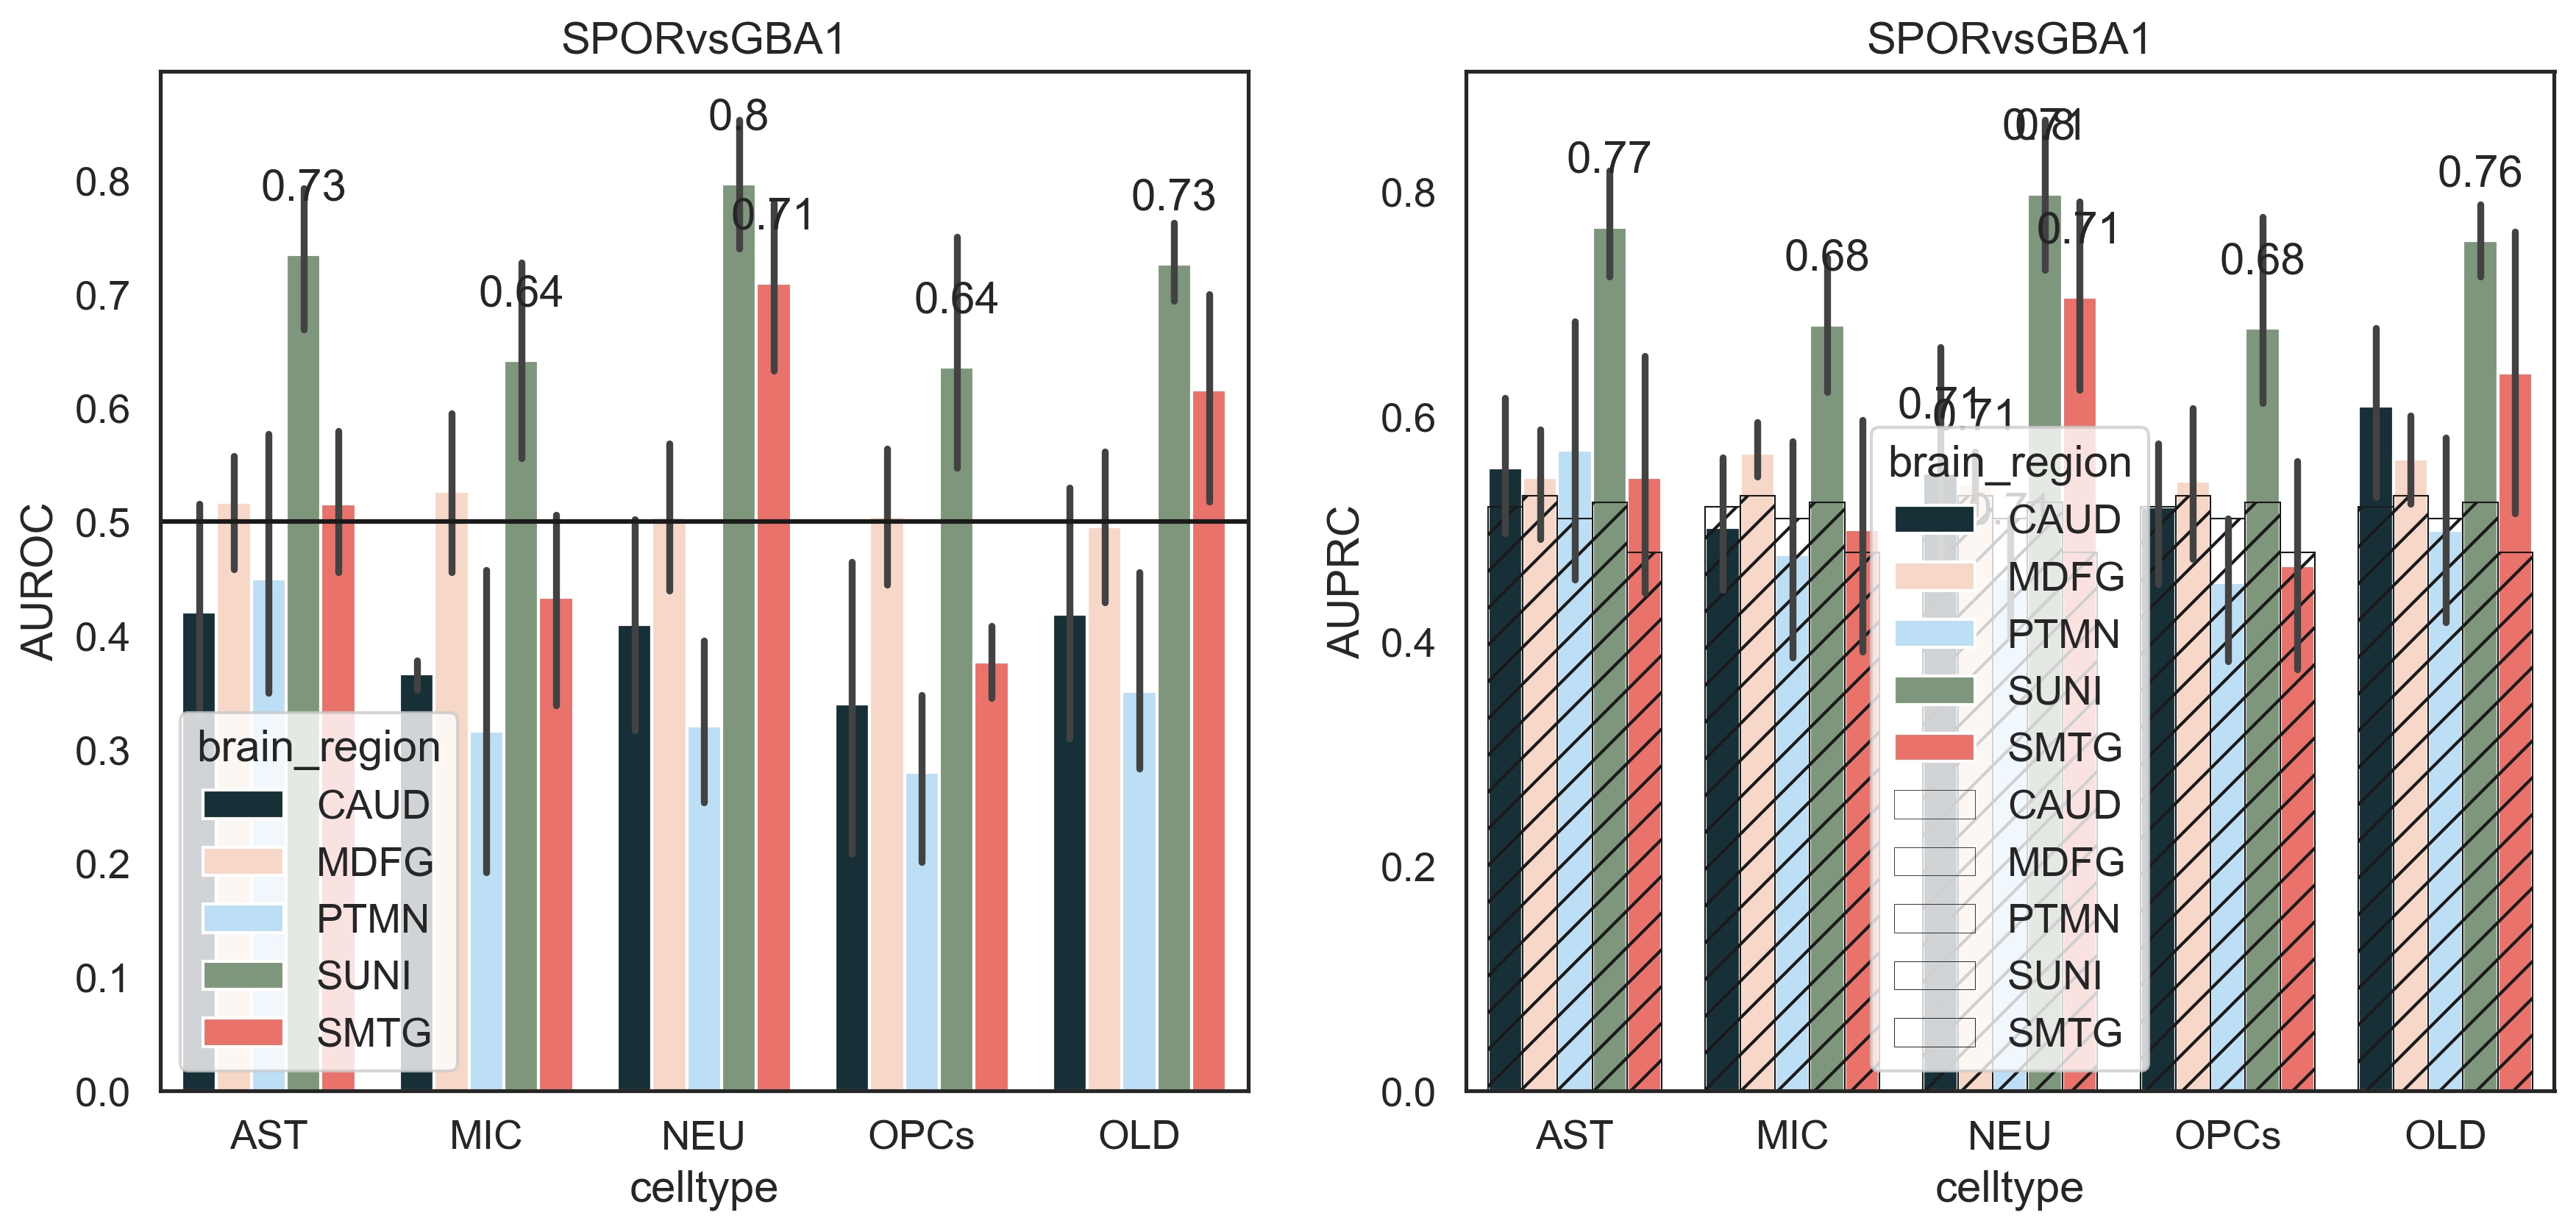

In [178]:

import seaborn as sns
# res = pd.read_pickle("Nested_cross_val_condition_without_sex.pickle")
final= tot[(tot.celltype!="bulk")&(tot.brain_region!="HIPP")]
cond = "SPOR$GBA1"
sns.set(style="white", font_scale=1.2)
# g = sns.FacetGrid(data=final, col="covar", col_wrap=3,height=4, aspect=1,)
# g.map_dataframe( x="celltype", y="AUROC", hue="brain_region", palette=COLORS_CT)#, style="model")

for cond in tot.comp.unique():
    final=tot[(tot.comp==cond) &(tot.brain_region!="HIPP")]
    # tb = final.groupby([ "brain_region",'celltype']).pval_auroc_plot.unique().reset_index()
    fig, axes = plt.subplots(1,2, figsize=(14,6))
    ax= axes[0]
    sns.barplot(data=final,x="celltype", y="AUROC", hue="brain_region", palette=COLORS_CT,ax=ax)#, errorbar="sd")
    ax.axhline(y=0.5, c="k")
    ax.set_title(cond.replace("$", "vs"))
    for container in ax.containers:
        au = [np.round(it,2) if it >0.62 else "" for it in container.datavalues]
        # lab = tb[tb.brain_region==container.get_label()].pval_auroc_plot.values.tolist()
        # lab = [str(it[0]) if au[ii] >0.5 else " " for ii,it in enumerate(lab)]
        # print(lab)
        # container.datavalues = np.array(lab)
        ax.bar_label(container, labels=au,padding=15, fmt="%s")
        #ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax= axes[1]
    sns.barplot(data=final,x="celltype", y="AUPRC", hue="brain_region", palette=COLORS_CT,ax=ax)#, errorbar="sd")
    # ax.axhline(y=0.5, c="k")
    ax.set_title(cond.replace("$", "vs"))
    
    for container in ax.containers:
        # print(container.get_label())
        # tt = final[(final["brain_region"] == container.get_label())]["prevalence"]#.iloc[0]
        # print(tt)
        # au = [np.round(it,2) if it >tt else "" for it in container.datavalues]
        # # lab = tb[tb.brain_region==container.get_label()].pval_auroc_plot.values.tolist()
        # lab = [str(it[0]) if au[ii] >0.5 else " " for ii,it in enumerate(lab)]
        # print(lab)
        # container.datavalues = np.array(lab)
        ax.bar_label(container, labels=au,padding=15, fmt="%s")
        #ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    sns.barplot(data=final,ax=ax, y = "prevalence", x="celltype", hue = "brain_region", fill=False,color="black", linewidth=0.2)#, legend=False)

    # ax[1].axvline(, c="k", linestyle="--", label"Pvalue<0.001")
    ax.set_ylabel("AUPRC")
    for i, bar in enumerate(ax.patches):
        if i >=25:
            bar.set_hatch("//")
            bar.set_edgecolor("k")
            bar.set_linewidth(0.5)
    for container in ax.containers:
        au = [np.round(it,2) if it >0.64 else "" for it in container.datavalues]
        ax.bar_label(container, labels=au,padding=15, fmt="%s")

plt.savefig("outdir/barplot_deconvoluted_auprc_auroc_cond_%s.svg"%cond.replace("/","-"))
plt.show()

In [34]:
pd.concat(res).groupby(["celltype"]).AUPRC.mean()

celltype
AST     0.768594
MIC     0.681664
NEU     0.798131
OLD     0.756735
OPCs    0.678475
Name: AUPRC, dtype: object

    Prediction score  input Cell type Brain region
0           0.229292  LRRK2       AST         SUNI
1           0.169115  LRRK2       AST         SUNI
2           0.412147  LRRK2       AST         SUNI
3           0.326815  LRRK2       AST         SUNI
4           0.658505   SPOR       AST         SUNI
..               ...    ...       ...          ...
755         0.906232   GBA1       OLD         SUNI
756         0.934284   GBA1       OLD         SUNI
757         0.977899   GBA1       OLD         SUNI
758         0.936028   GBA1       OLD         SUNI
759         0.967317   GBA1       OLD         SUNI

[760 rows x 4 columns]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MIC_SPOR vs. MIC_GBA1: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.586e-03 U_stat=1.945e+03
NEU_SPOR vs. NEU_GBA1: Mann-Whitney-Wilcoxo

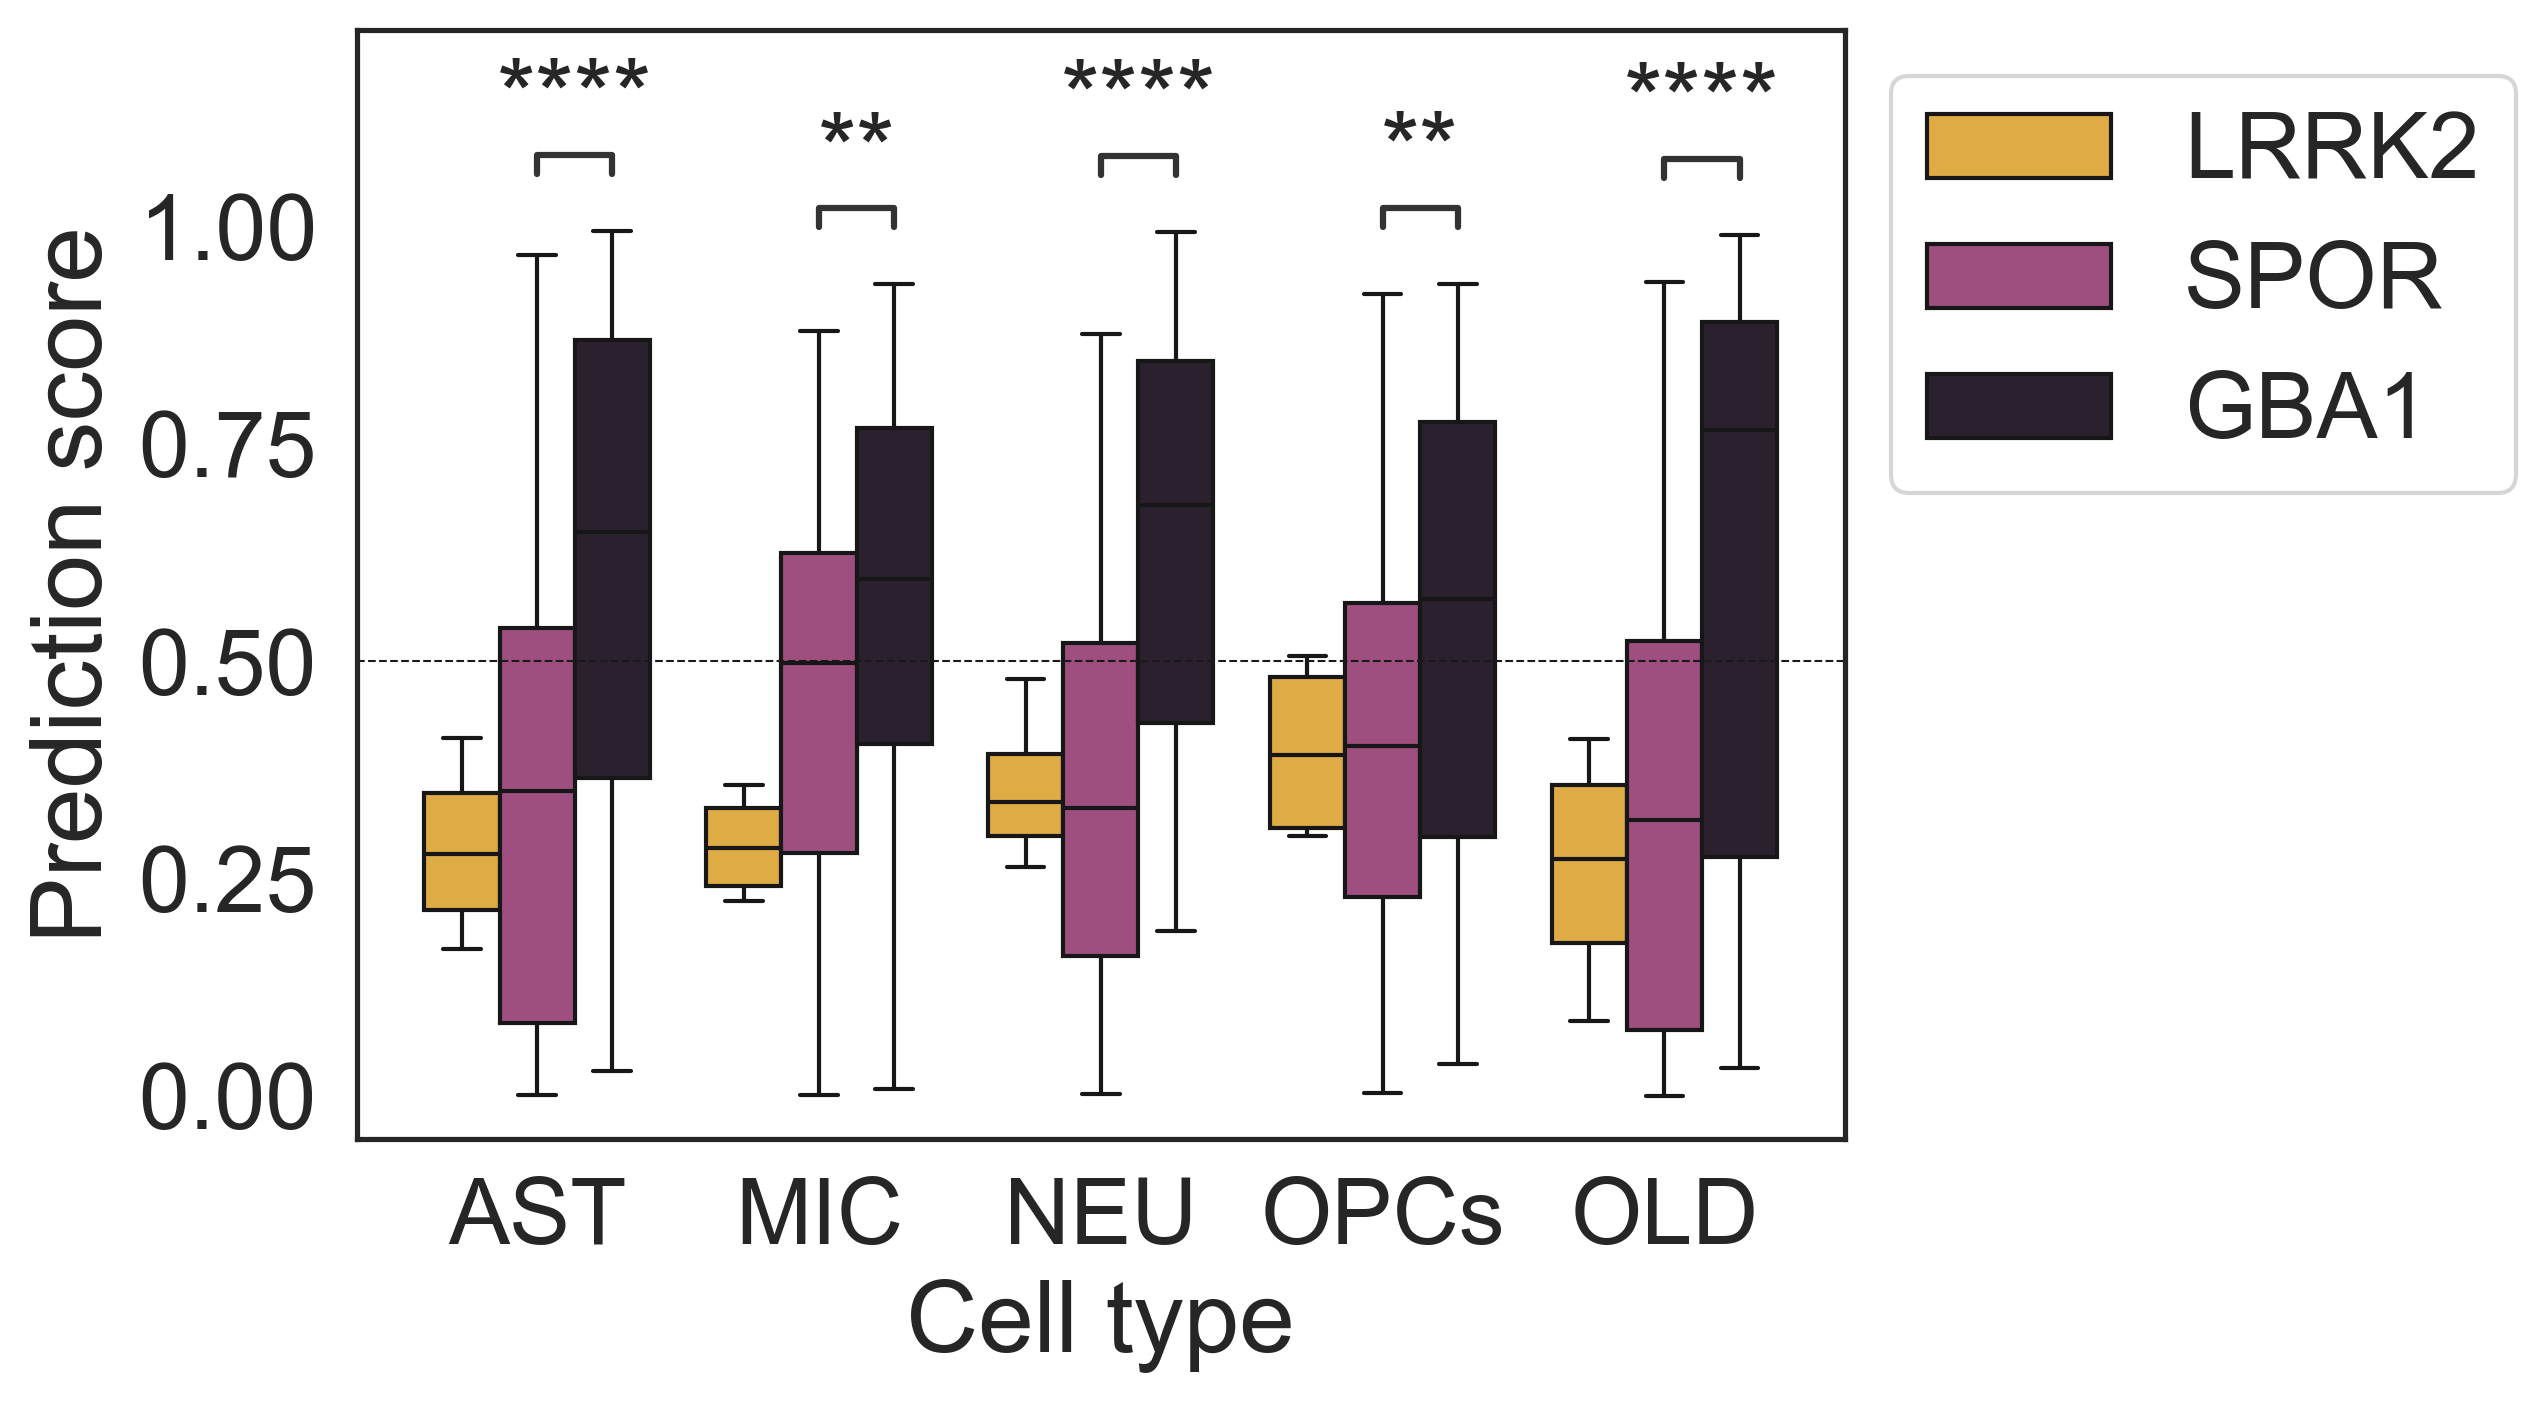

In [165]:
all = []
REGION = "SUNI"
for br in [REGION]:
    for ct in celltypes:
        if ct!="bulk":

            dico_ = dico["%s_%s"%(br, ct)]
            
            # y_preds = dico_["y_preds"]
            # y_preds = dico_["preds"].mean(1)
            # test = dico_["tests"].mean(1)
            # # y_test = dico_["y_tests"]
            # y_gba1 = y_preds[test==1]
            # y_spor = y_preds[test==0]

            y_preds = dico_["preds"].values.flatten()
            test = dico_["tests"].values.flatten()
            y_gba1 = y_preds[test==1]
            y_spor = y_preds[test==0]
            y_lrrk2 = pd.DataFrame(dico_["y_lrrk2"],columns=["Prediction score"])
            y_lrrk2["input"] = "LRRK2"
            y_spor = pd.DataFrame(y_spor,columns=["Prediction score"])
            y_spor["input"] = "SPOR"
            y_gba1 = pd.DataFrame(y_gba1,columns=["Prediction score"])
            y_gba1["input"] = "GBA1"
            df_ = pd.concat([y_lrrk2, y_spor, y_gba1])
            df_["Cell type"] = ct
            df_["Brain region"] = br
            all.append(df_)
all = pd.concat(all)
all.reset_index(drop=True, inplace=True)
print(all)




toplot = all[all["Brain region"] ==REGION]

all["Prediction score"] = all["Prediction score"].astype(float)

ax = sns.boxplot(data=all, x="Cell type", y="Prediction score", hue="input", palette=COLORS_CT, dodge=True)
# sns.stripplot(data=all, x="Cell type", y="Prediction score", hue="input", color="#ababab",s=2, dodge=True, ax=ax)
ax.legend(bbox_to_anchor=(1,1))
ax.axhline(0.5, c="k", linestyle="--", linewidth=0.5)
# pairs=[((ct,"GBA1"),(ct,"CTRL"))for ct in all["Cell type"].unique()]
#pairs+=[((ct,"SPOR"),(ct,"LRRK2_PD+"))for ct in all["Cell type"].unique()]
# pairs+=[((ct,"SPOR"),(ct,"CTRL"))for ct in all["Cell type"].unique()]
#pairs+=[((ct,"GBA1_PD+"),(ct,"LRRK2_PD+"))for ct in all["Cell type"].unique()]
pairs=[((ct,"GBA1"),(ct,"SPOR"))for ct in all["Cell type"].unique()]

annotator= Annotator(ax,pairs,data=all,x="Cell type", y="Prediction score", hue="input")
annotator.configure(test='Mann-Whitney', text_format='star',comparisons_correction='fdr_bh')
annotator.apply_and_annotate()
plt.savefig("./outdir/boxplot_prediction_score_deconvoluted_gba1_spor_%s.svg"%REGION)   


In [166]:
phenotype = ["CTRL","SPOR", "GBA1/PD+",  "LRRK2/PD+", "GBA1/PD-", "LRRK2/PD-"]
# pathology = ["Neocortical LB", "Brainstem/Limbic LB","Neuritic plaque density binary", "Braak score NFT binary"]#, "xxx.obt",'xxx.brain_stem_ix_x', 'xxx.brain_stem_lc', 'xxx.bf_amygdala', 'xxx.brain_stem_sn',
           # 'xxx.bf_trans', 'xxx.bf_cing', 'xxx.nctx_temporal', 'xxx.nctx_frontal','xxx.nctx_parietal']
functional = [ "PD path", "AD path", "Cognitive Imp"]
genotype= ["ApoE_2", "ApoE_4"]

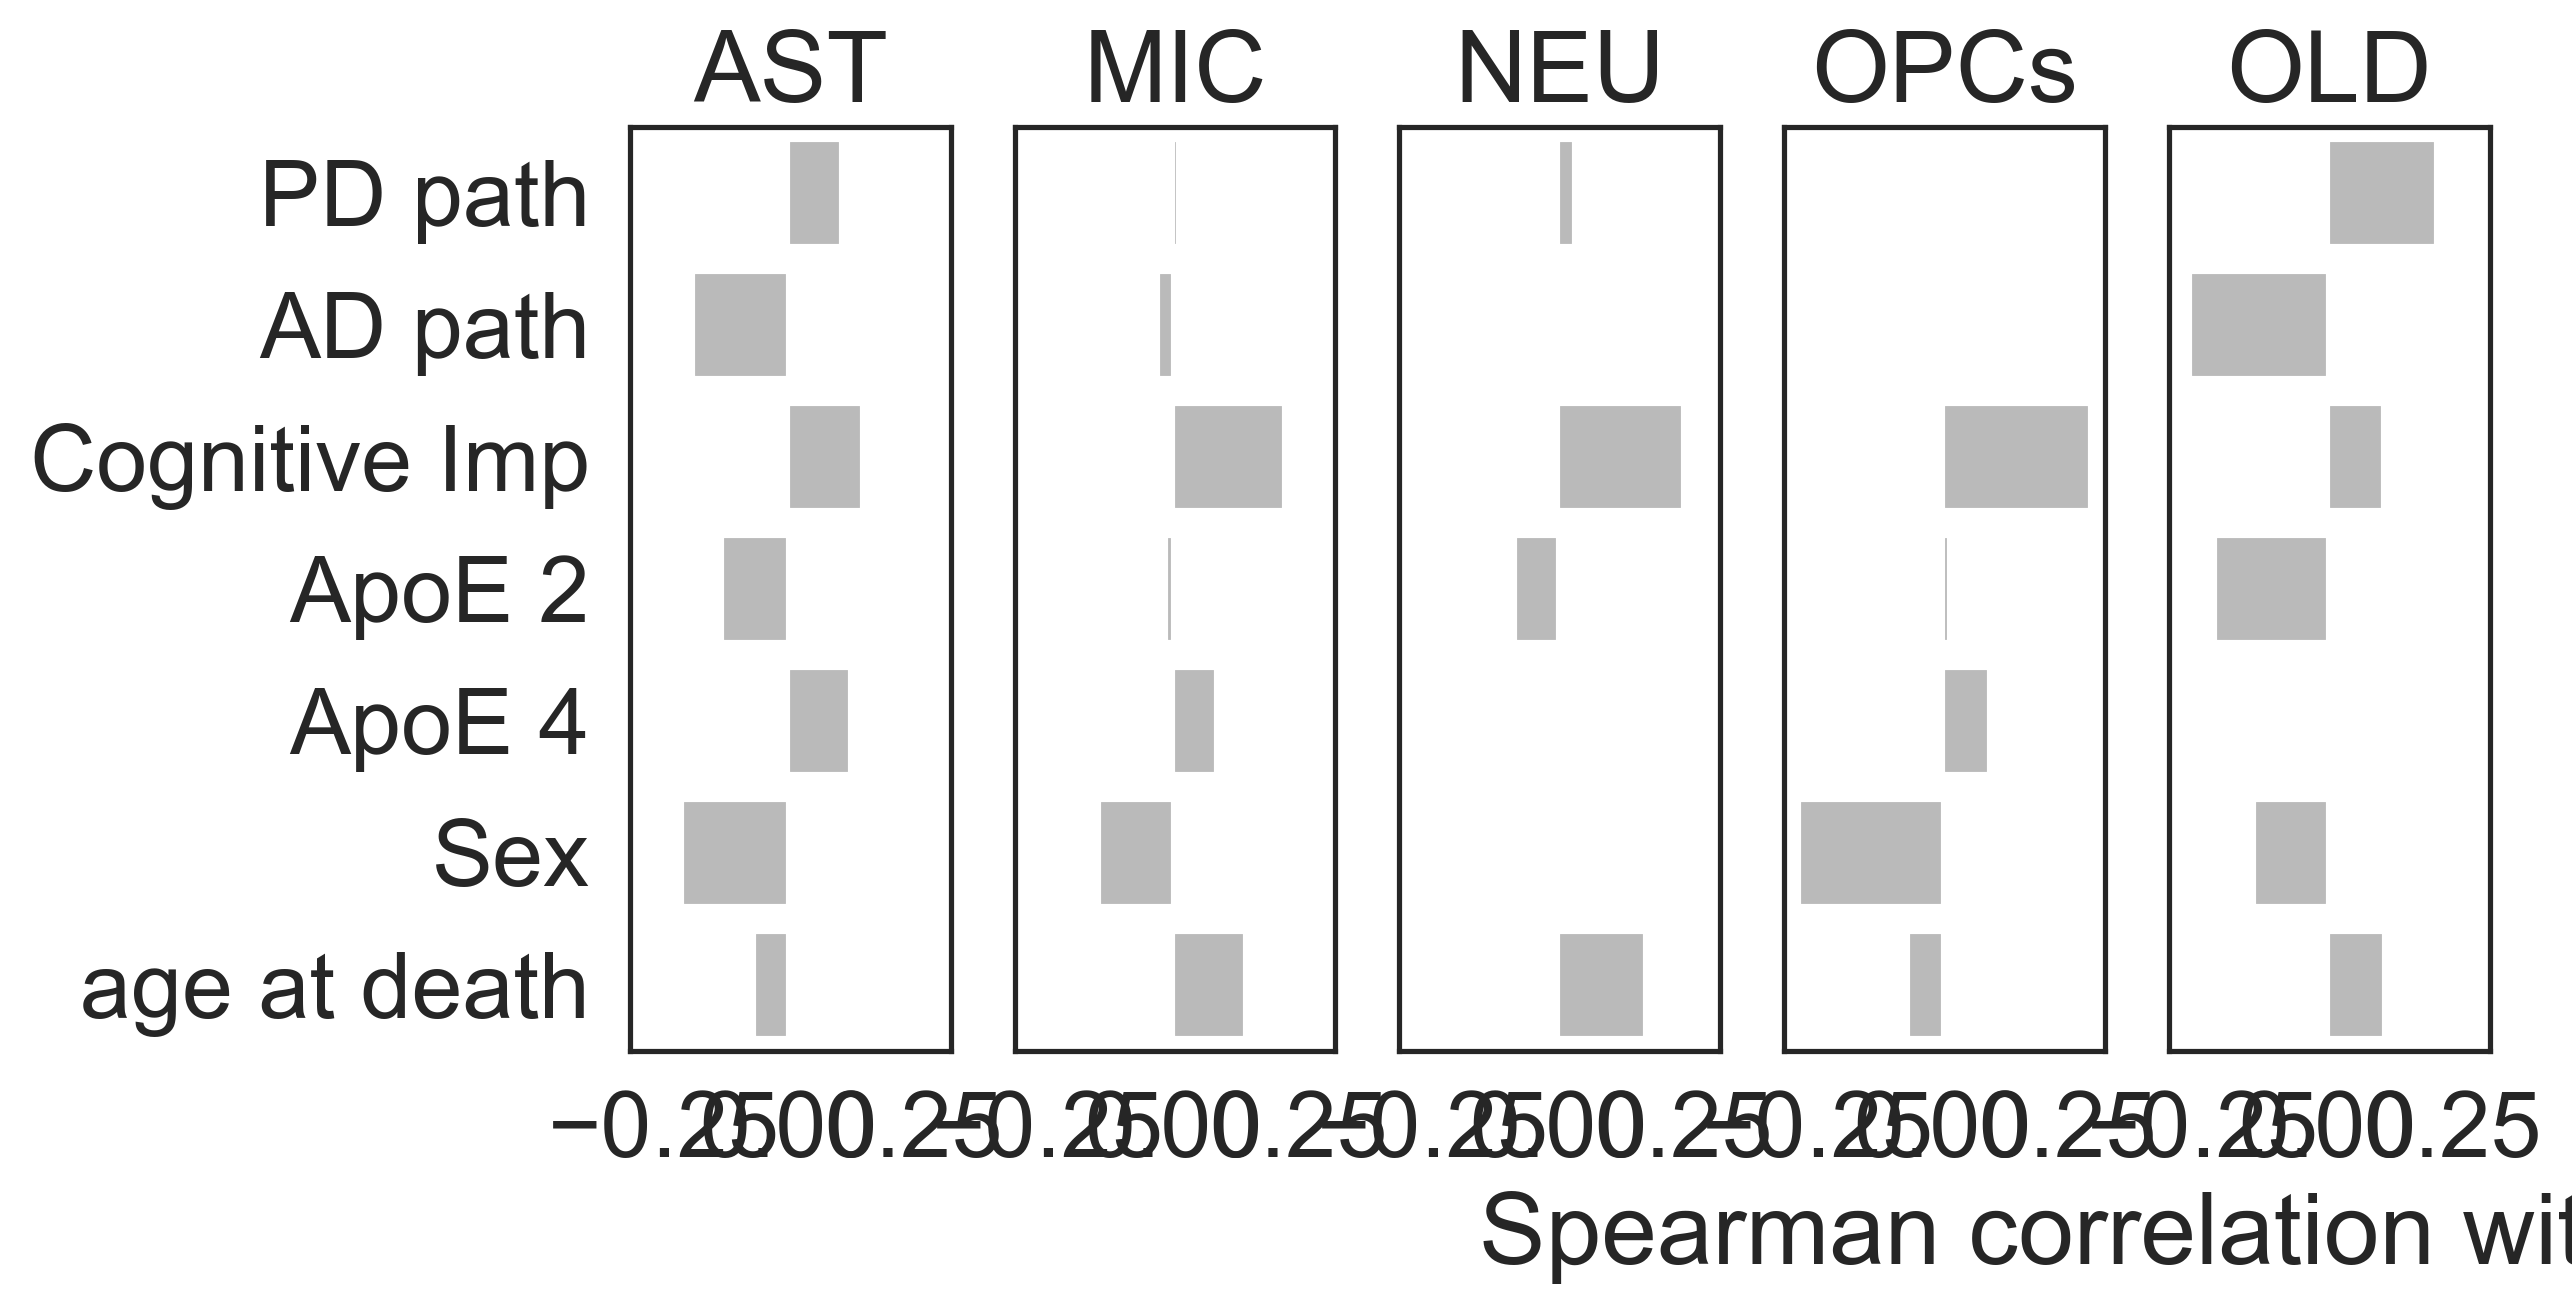

        PD path   AD path  Cognitive Imp    ApoE_2   ApoE_4       Sex  \
error  0.651739  1.233334       1.122485  0.648974  0.50766  1.854758   

       age at death  
error      0.013134  
        PD path   AD path  Cognitive Imp    ApoE_2   ApoE_4       Sex  \
error  0.651739  1.233334       1.122485  0.648974  0.50766  1.854758   

       age at death  
error      0.013134  
        PD path   AD path  Cognitive Imp    ApoE_2    ApoE_4       Sex  \
error  0.491233  0.371833       1.173986  0.202659  0.538993  0.777696   

       age at death  
error      0.853759  
        PD path   AD path  Cognitive Imp    ApoE_2    ApoE_4       Sex  \
error  0.491233  0.371833       1.173986  0.202659  0.538993  0.777696   

       age at death  
error      0.853759  
        PD path   AD path  Cognitive Imp    ApoE_2    ApoE_4       Sex  \
error  0.236124  0.126705       2.352419  0.508824  0.148312  0.225572   

       age at death  
error       0.97769  
        PD path   AD path  Cognitive Im

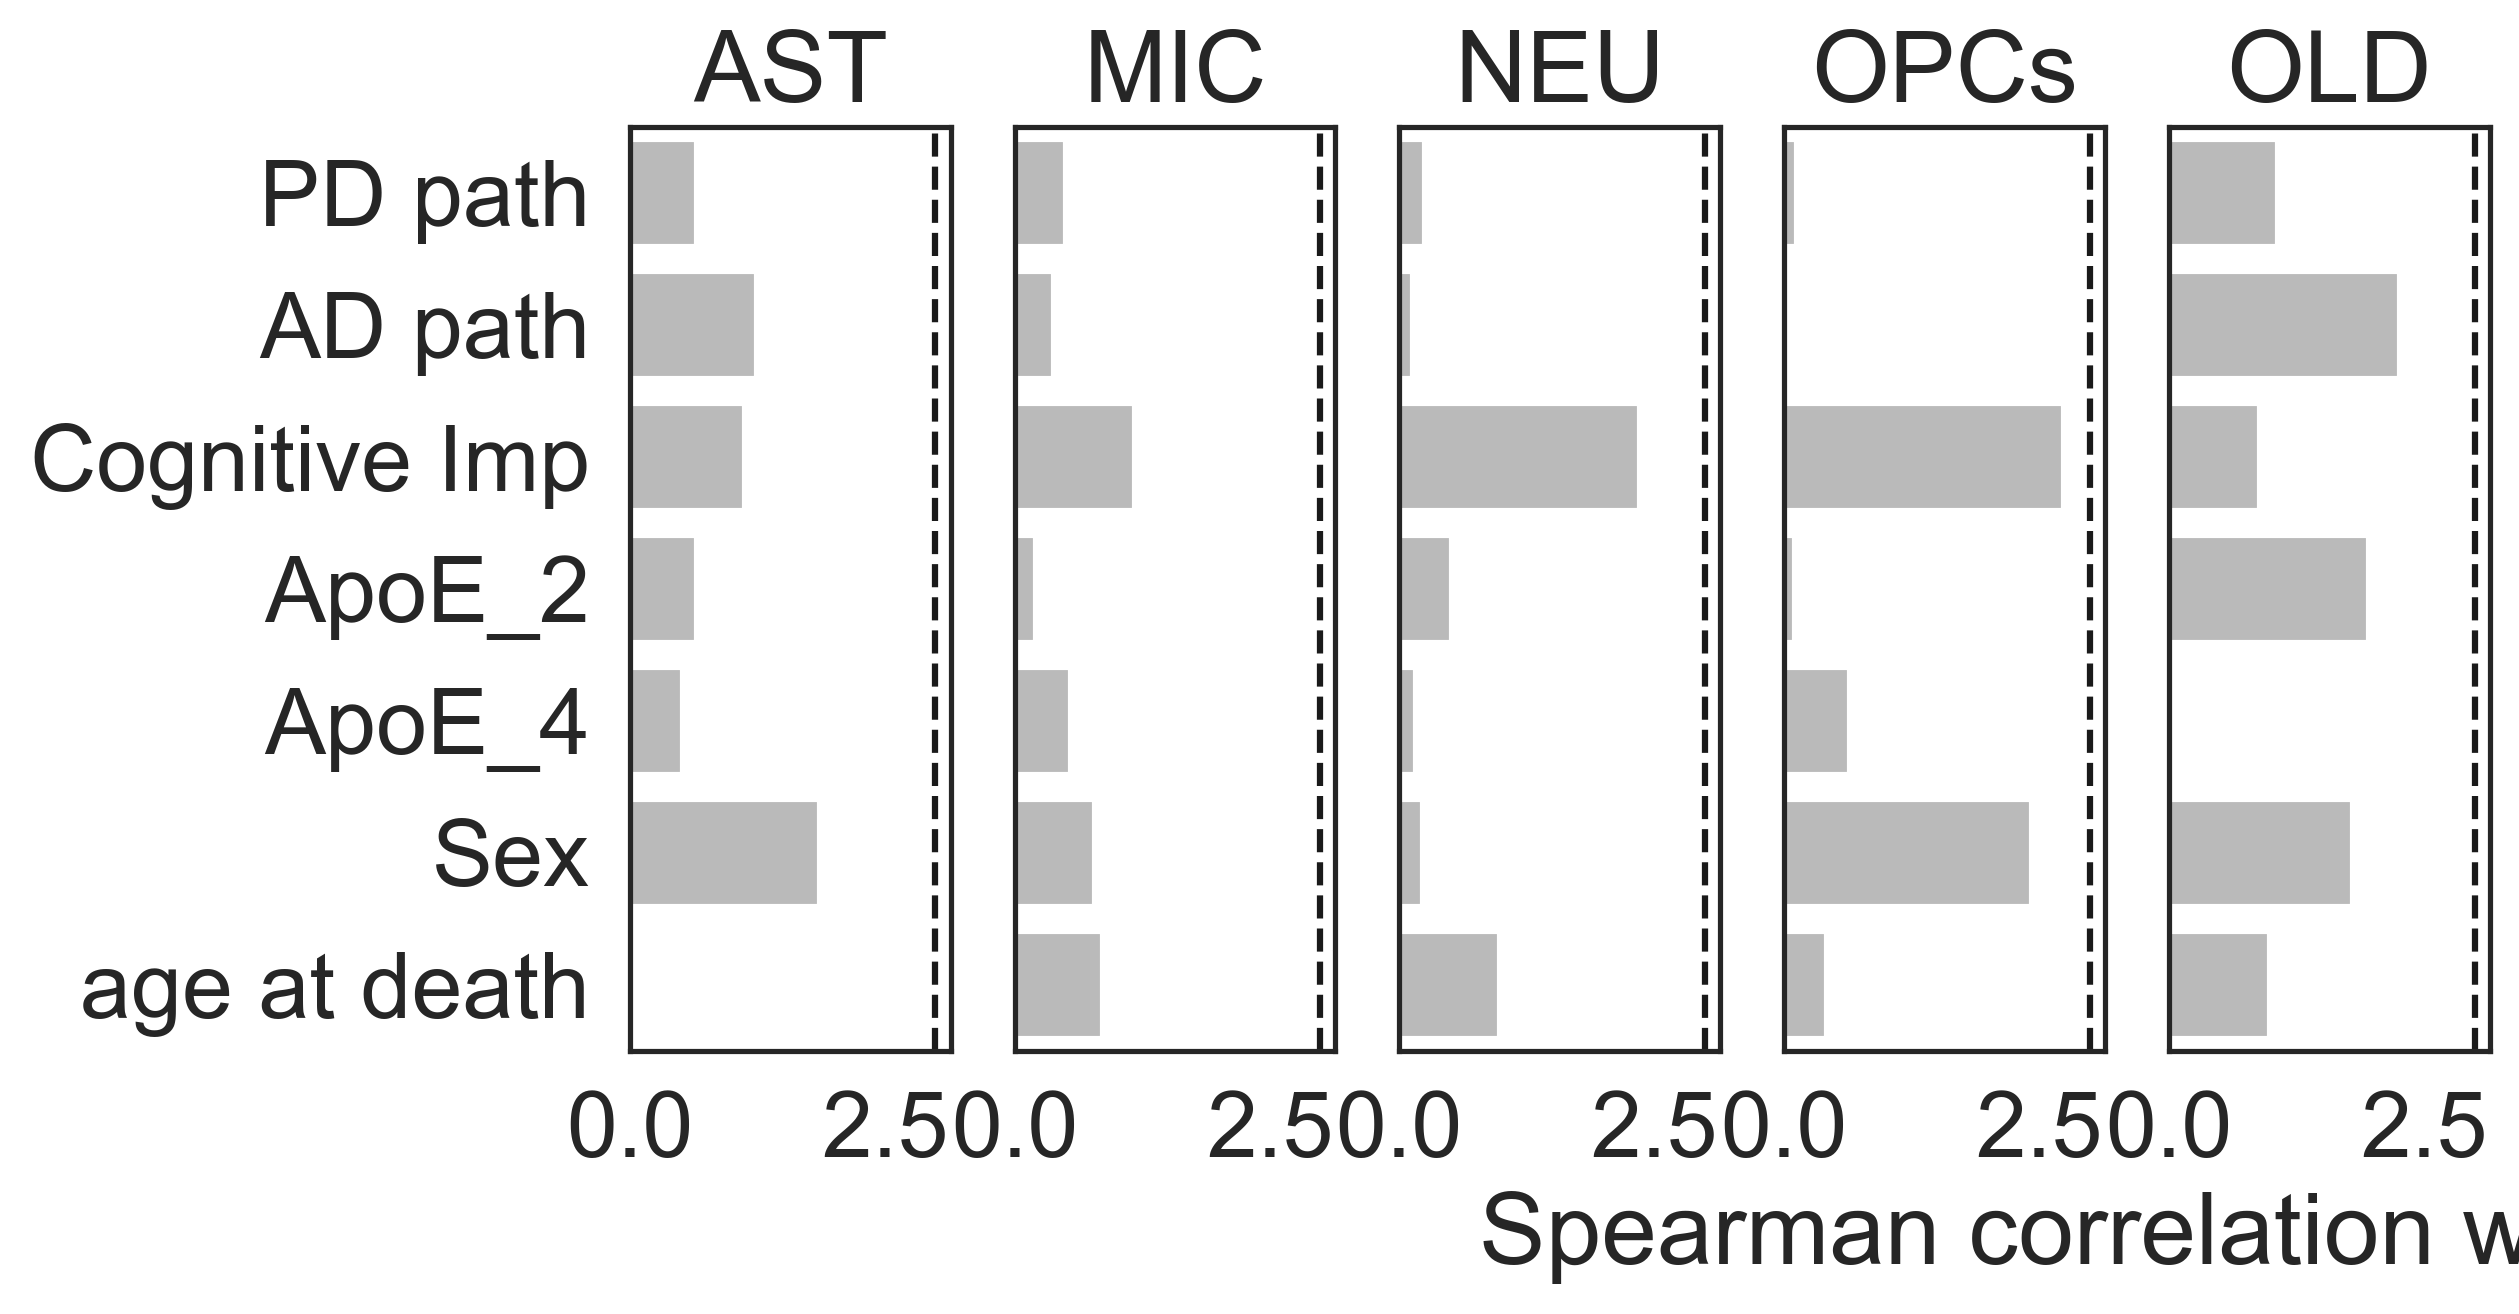

In [168]:
C1 = "#45556B"
C2="#BABABA"


def getpvalue(x, y):
    _, pval = pearsonr(x,y)
    return pval

fig, axes =plt.subplots(1,5, figsize=(8,4),sharey=True, sharex=True)
axes = axes.flatten()
ii =0
for ct in celltypes:
    if ct !="bulk":
        ax = axes[ii]
        dico_ = dico["%s_%s"%(REGION,ct)]
        meta = dico_["meta"].copy()
        meta["error"] = dico_["y_error"].mean(1).values
        mat_p = meta[ genotype + functional + ["error", "Sex","age at death"]].replace({"no":0., "yes":1., "low/no":0., "moderate/high":1.,"Male":0., "Female":1.}).astype(float).corr(getpvalue)
        
        mat = meta[genotype +functional + ["error","Sex","age at death"]].replace({"no":0., "yes":1., "low/no":0., "moderate/high":1., "Male":0., "Female":1.}).astype(float).corr(method="pearson")#getpvalue)
        mat_p.loc[:,:] = -np.log(mat_p*len(genotype +functional + ["Sex","age at death"]))
        mat = mat.loc[["error"], functional + genotype+ ["Sex","age at death"]]#+["Sex", "age at death", "PMI"]]
        mat_p = mat_p.loc[["error"], functional + genotype+["Sex","age at death"]]#+["Sex", "age at death", "PMI"]]
        
        mat.columns = [it.replace("xxx.","").replace("_", " ") for it in mat.columns.tolist()]
        mat_p.columns = [it.replace("xxx.","") for it in mat_p.columns.tolist()]
        
        
        palette= {"ns": C2, "sig":C1}
        color = [palette["sig"] if it > -np.log(0.049) else palette["ns"] for it in mat_p.T.values.tolist()]
        
        sns.barplot(data=mat, orient="h", ax=ax, palette=color)
        # ax.axvline(-np.log(0.049), c="k", linestyle="--")
        # mat
        # ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
        ax.set_title(ct)
        ii+=1
plt.xlabel("Spearman correlation with model error")

plt.savefig("./outdir/model_error_analysis_all_%s.svg"%REGION)
plt.show()

def getpvalue(x, y):
    _, pval = spearmanr(x,y)
    return pval

fig, axes =plt.subplots(1,5, figsize=(8,4),sharey=True, sharex=True)
axes = axes.flatten()
ii =0
for ct in celltypes:
    if ct !="bulk":
        ax = axes[ii]
        dico_ = dico["SUNI_%s"%ct]
        meta = dico_["meta"].copy()
        meta["error"] = dico_["y_error"].mean(1).values
        mat_p = meta[ genotype + functional + ["error", "Sex","age at death"]].replace({"no":0., "yes":1.,
                                                                                "low/no":0., "moderate/high":1.,"Male":0.,
                                                                                "Female":1.}).astype(float).corr(getpvalue)
 
        mat = meta[genotype +functional + ["error","Sex","age at death"]].replace({"no":0., "yes":1., "low/no":0.,
                                                                           "moderate/high":1., "Male":0., "Female":1.}).astype(float).corr(method="spearman")#getpvalue)
        
        
       
        mat = mat.loc[["error"], functional + genotype+ ["Sex","age at death"]]#+["Sex", "age at death", "PMI"]]
        mat_p = mat_p.loc[["error"], functional + genotype+["Sex", "age at death"]]#+["Sex", "age at death", "PMI"]]
        mat.columns = [it.replace("xxx.","").replace("_", " ") for it in mat.columns.tolist()]
        mat_p.columns = [it.replace("xxx.","") for it in mat_p.columns.tolist()]
        

        mat_p.loc[:,:] = -np.log(np.clip(mat_p,0,1))
        print(mat_p)
        
        color = [palette["sig"] if it > -np.log(0.049) else palette["ns"] for it in mat_p.T.values.tolist()]
        print(mat_p)
        sns.barplot(data=mat_p, orient="h", ax=ax, palette=color)
        ax.axvline(-np.log(0.05), c="k", linestyle="--")
        # mat
        # ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
        ax.set_title(ct)
        ii+=1
plt.xlabel("Spearman correlation with model error")

plt.savefig("./outdir/model_error_analysis_all_pval_%s.svg"%REGION)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MIC_Female vs. MIC_Male: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:9.671e-01 U_stat=3.500e+01
AST_Female vs. AST_Male: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:2.269e-01 U_stat=2.100e+01
NEU_Female vs. NEU_Male: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:9.023e-01 U_stat=3.400e+01
OPCs_Female vs. OPCs_Male: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:2.622e-01 U_stat=2.200e+01
OLD_Female vs. OLD_Male: Mann-Whitney-Wilcoxon test two-sided with Holm-Bonferroni correction, P_val:5.381e-01 U_stat=2.800e+01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03

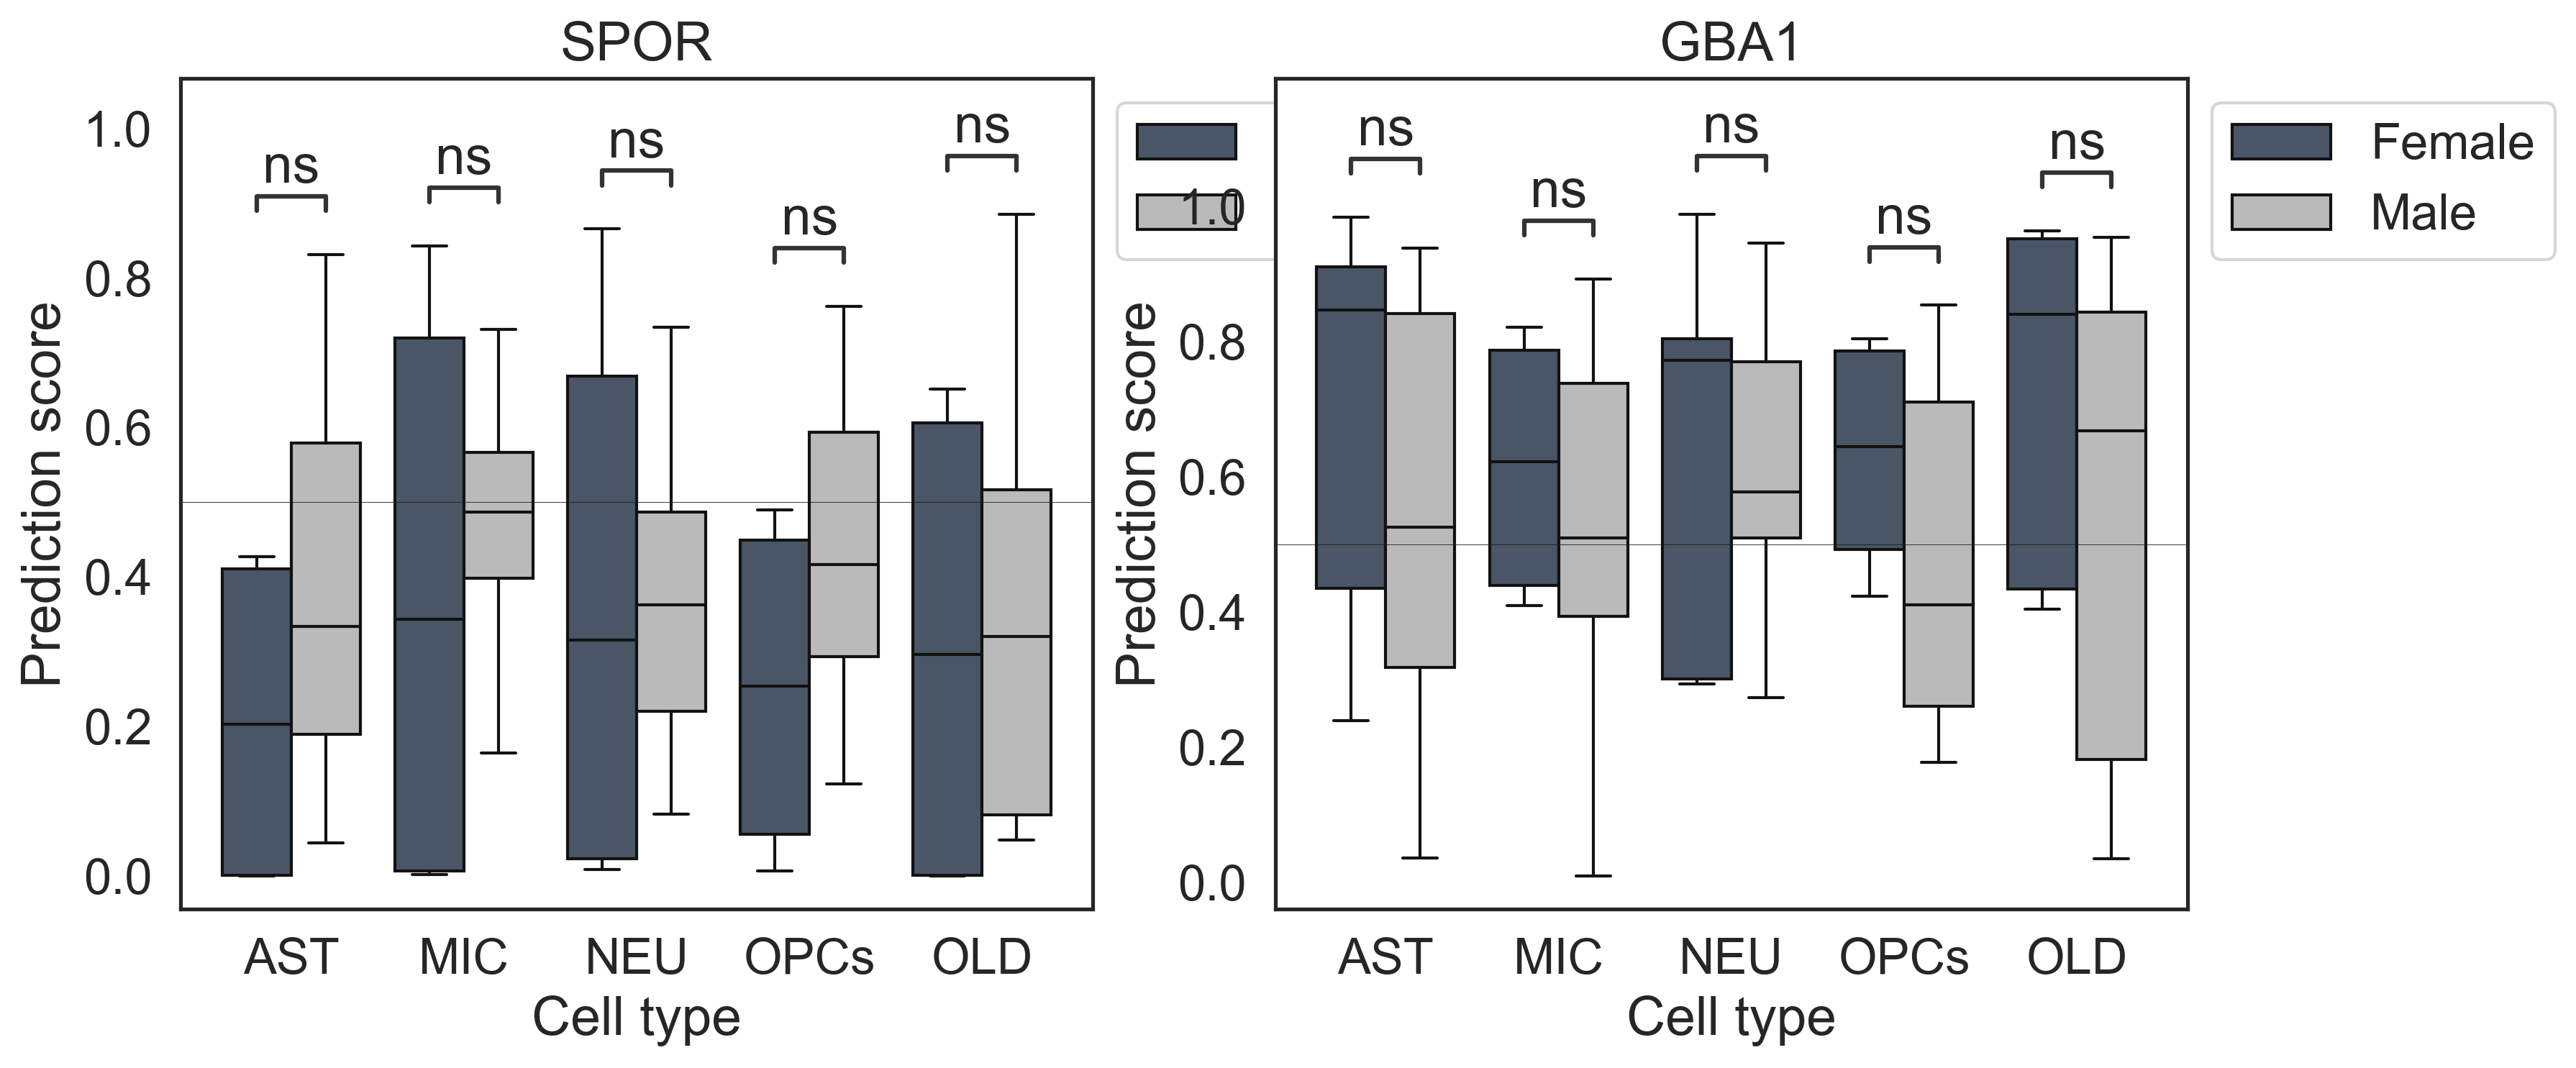

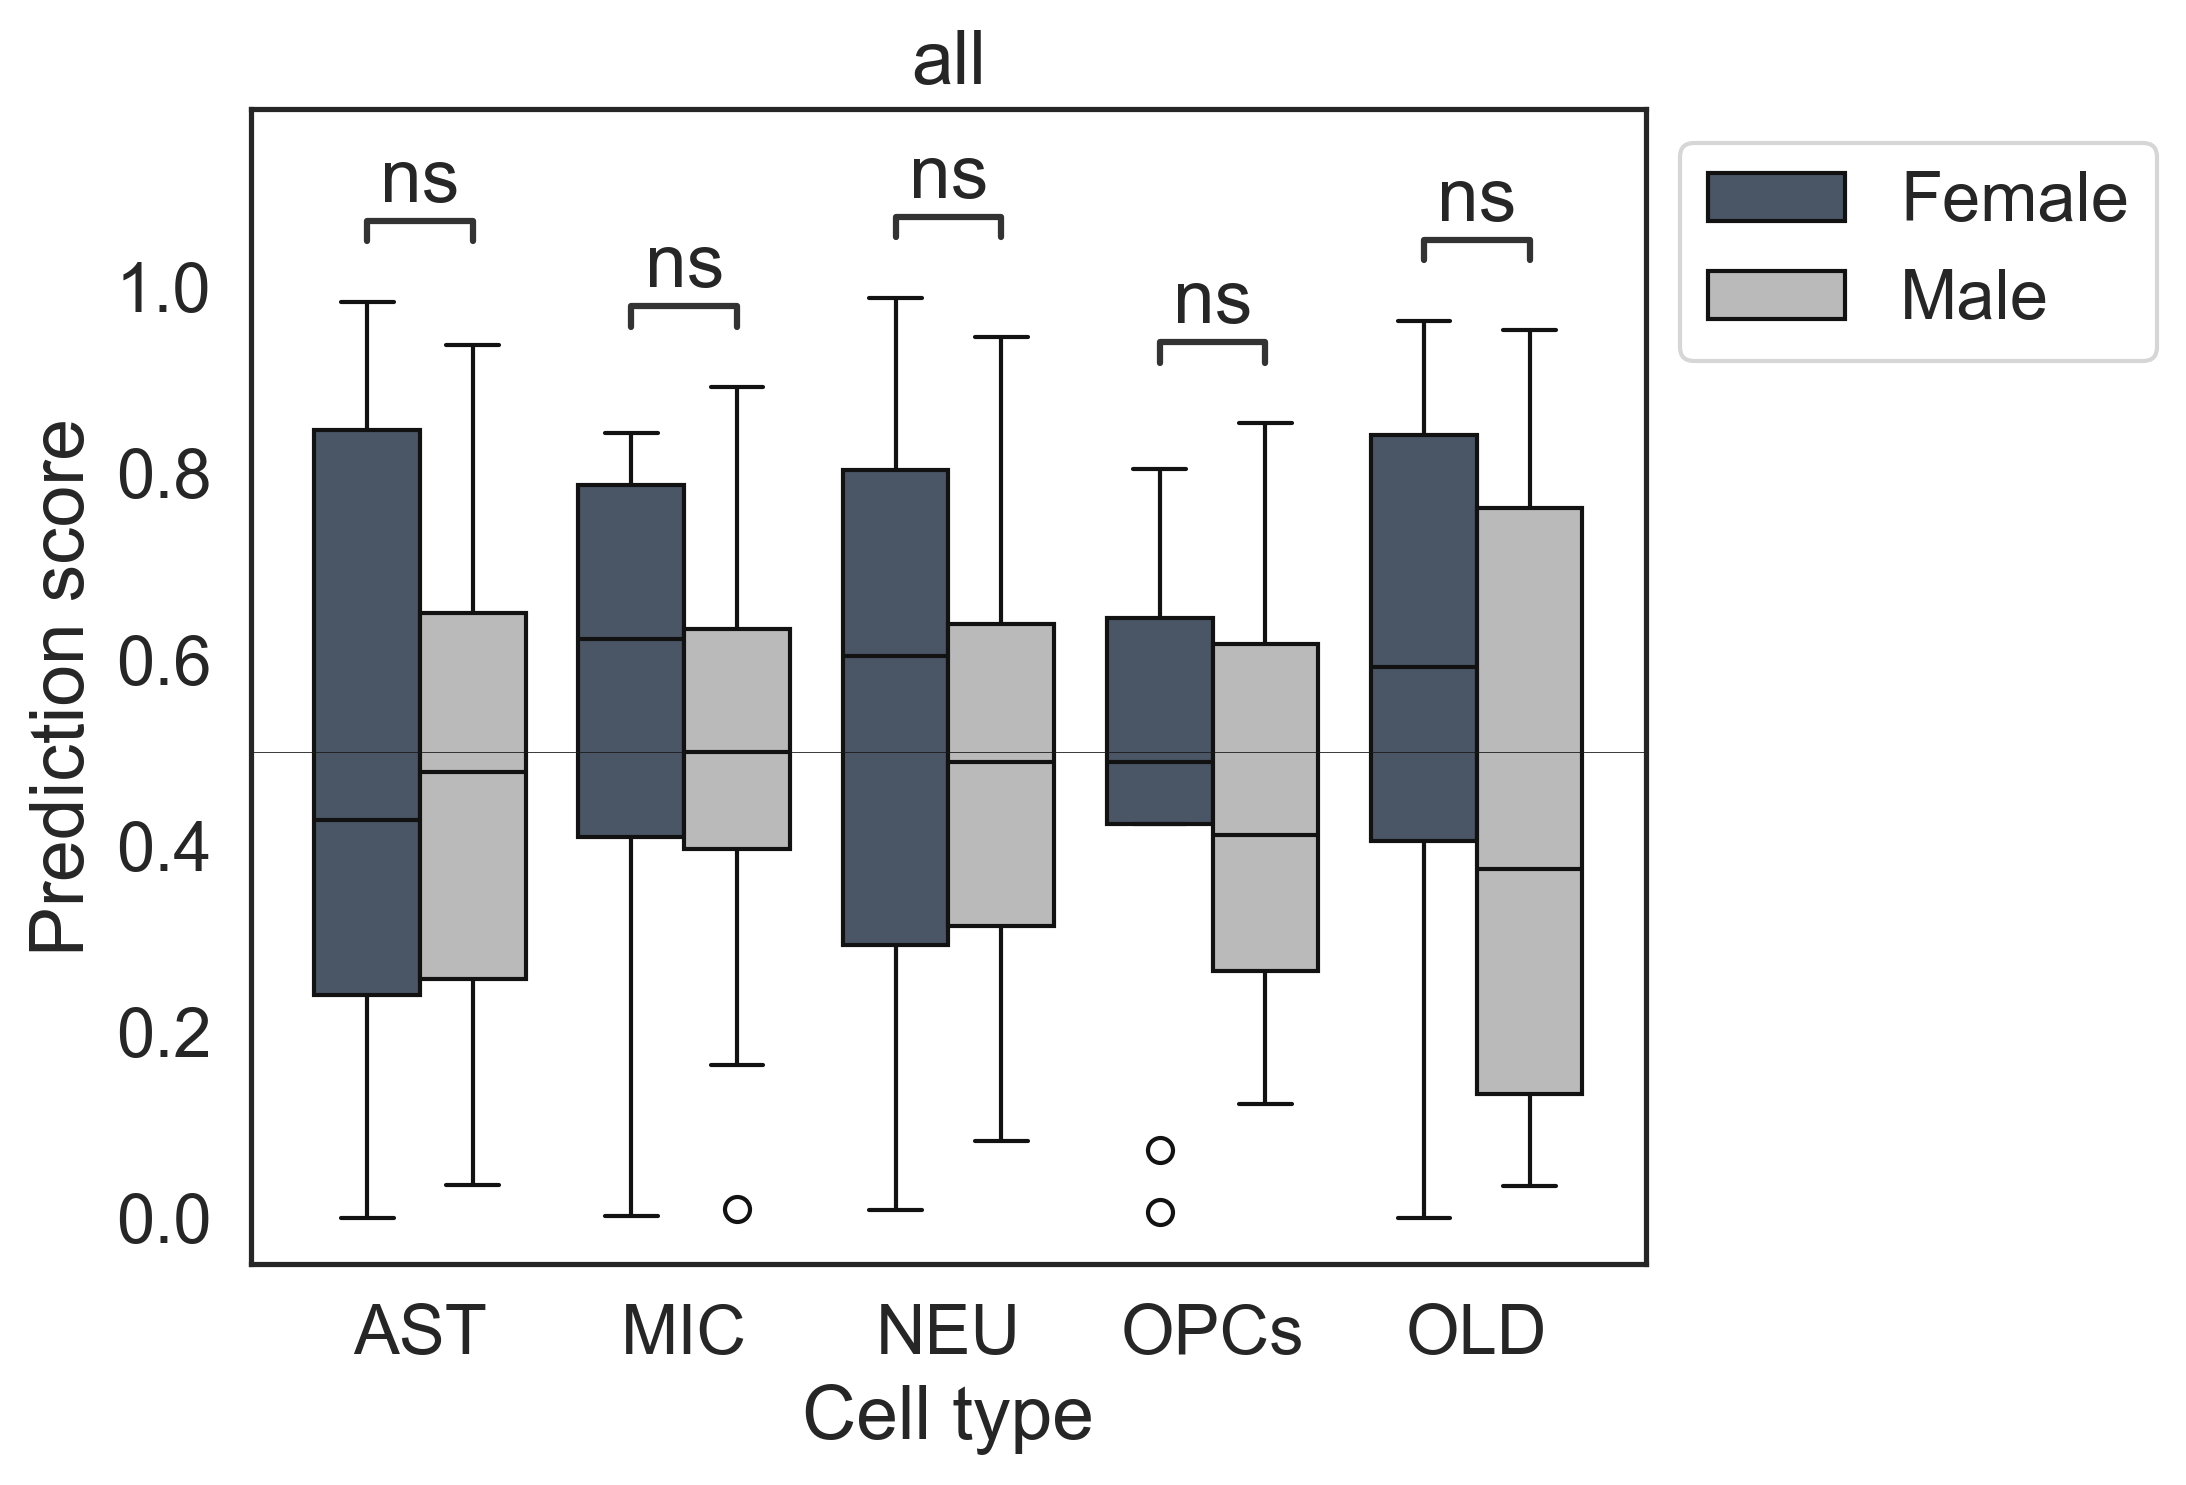

In [108]:
ct = "AST"
all = []
for ct in celltypes:
    if ct !="bulk":
        dico_ = dico["%s_%s"%(REGION,ct)]
        meta = dico_["meta"].copy()
        meta["Prediction score"] = dico_["preds"].mean(1).values.astype(float)

        meta["Cell type"] = ct
        all.append(meta)
all = pd.concat(all)
palette_cov = {"Female":C1,"Male":C2, "sig":"#003C30"}

fig, axes = plt.subplots(1,2, figsize=(12,5))
x = "Prediction score"
all[x] = all[x].astype(float)
sns.set(style="white", font_scale=1.5)
for ii, it in enumerate(all.condition.unique()):
    ax=axes[ii]
    sns.boxplot(data=all[all.condition==it], ax=ax, y=x,x="Cell type", hue="Sex", palette=palette_cov)
    ax.legend(bbox_to_anchor=(1,1))
    pairs=[((ct,"Female"),(ct,"Male"))for ct in all["Cell type"].unique()]
    ax.axhline(0.5,c="k", linewidth=0.2)

    annotator= Annotator(pairs=pairs,data=all[all.condition==it], ax=ax, y=x,x="Cell type", hue="Sex")
    annotator.configure(test='Mann-Whitney', text_format='star',comparisons_correction='Holm-Bonferroni')
    annotator.apply_and_annotate()
    ax.set_title(it)
plt.savefig("./outdir/boxplot_prediction_stratified_by_sex_gba1_spor_%s.svg"%REGION)   





fig, axes = plt.subplots(1,1, figsize=(6,5))

all[x] = all[x].astype(float)
# for ii, it in enumerate(all.condition.unique()):
if True:
    ax=axes#[ii]
    sns.boxplot(data=all, ax=ax, y=x,x="Cell type", hue="Sex", palette=palette_cov)
    ax.legend(bbox_to_anchor=(1,1))
    ax.axhline(0.5,c="k", linewidth=0.2)

    annotator= Annotator(pairs=pairs,data=all, ax=ax, y=x,x="Cell type", hue="Sex")
    annotator.configure(test='Mann-Whitney', text_format='star',comparisons_correction='Holm-Bonferroni')
    annotator.apply_and_annotate()
    ax.set_title("all")
plt.savefig("./outdir/boxplot_prediction_stratified_by_sex_gba1_spor_all_%.svg"%REGION) 

['Neocortical LB' 'Brainstem/Limbic LB' nan]
AST
MIC
NEU
OLD
OPCs


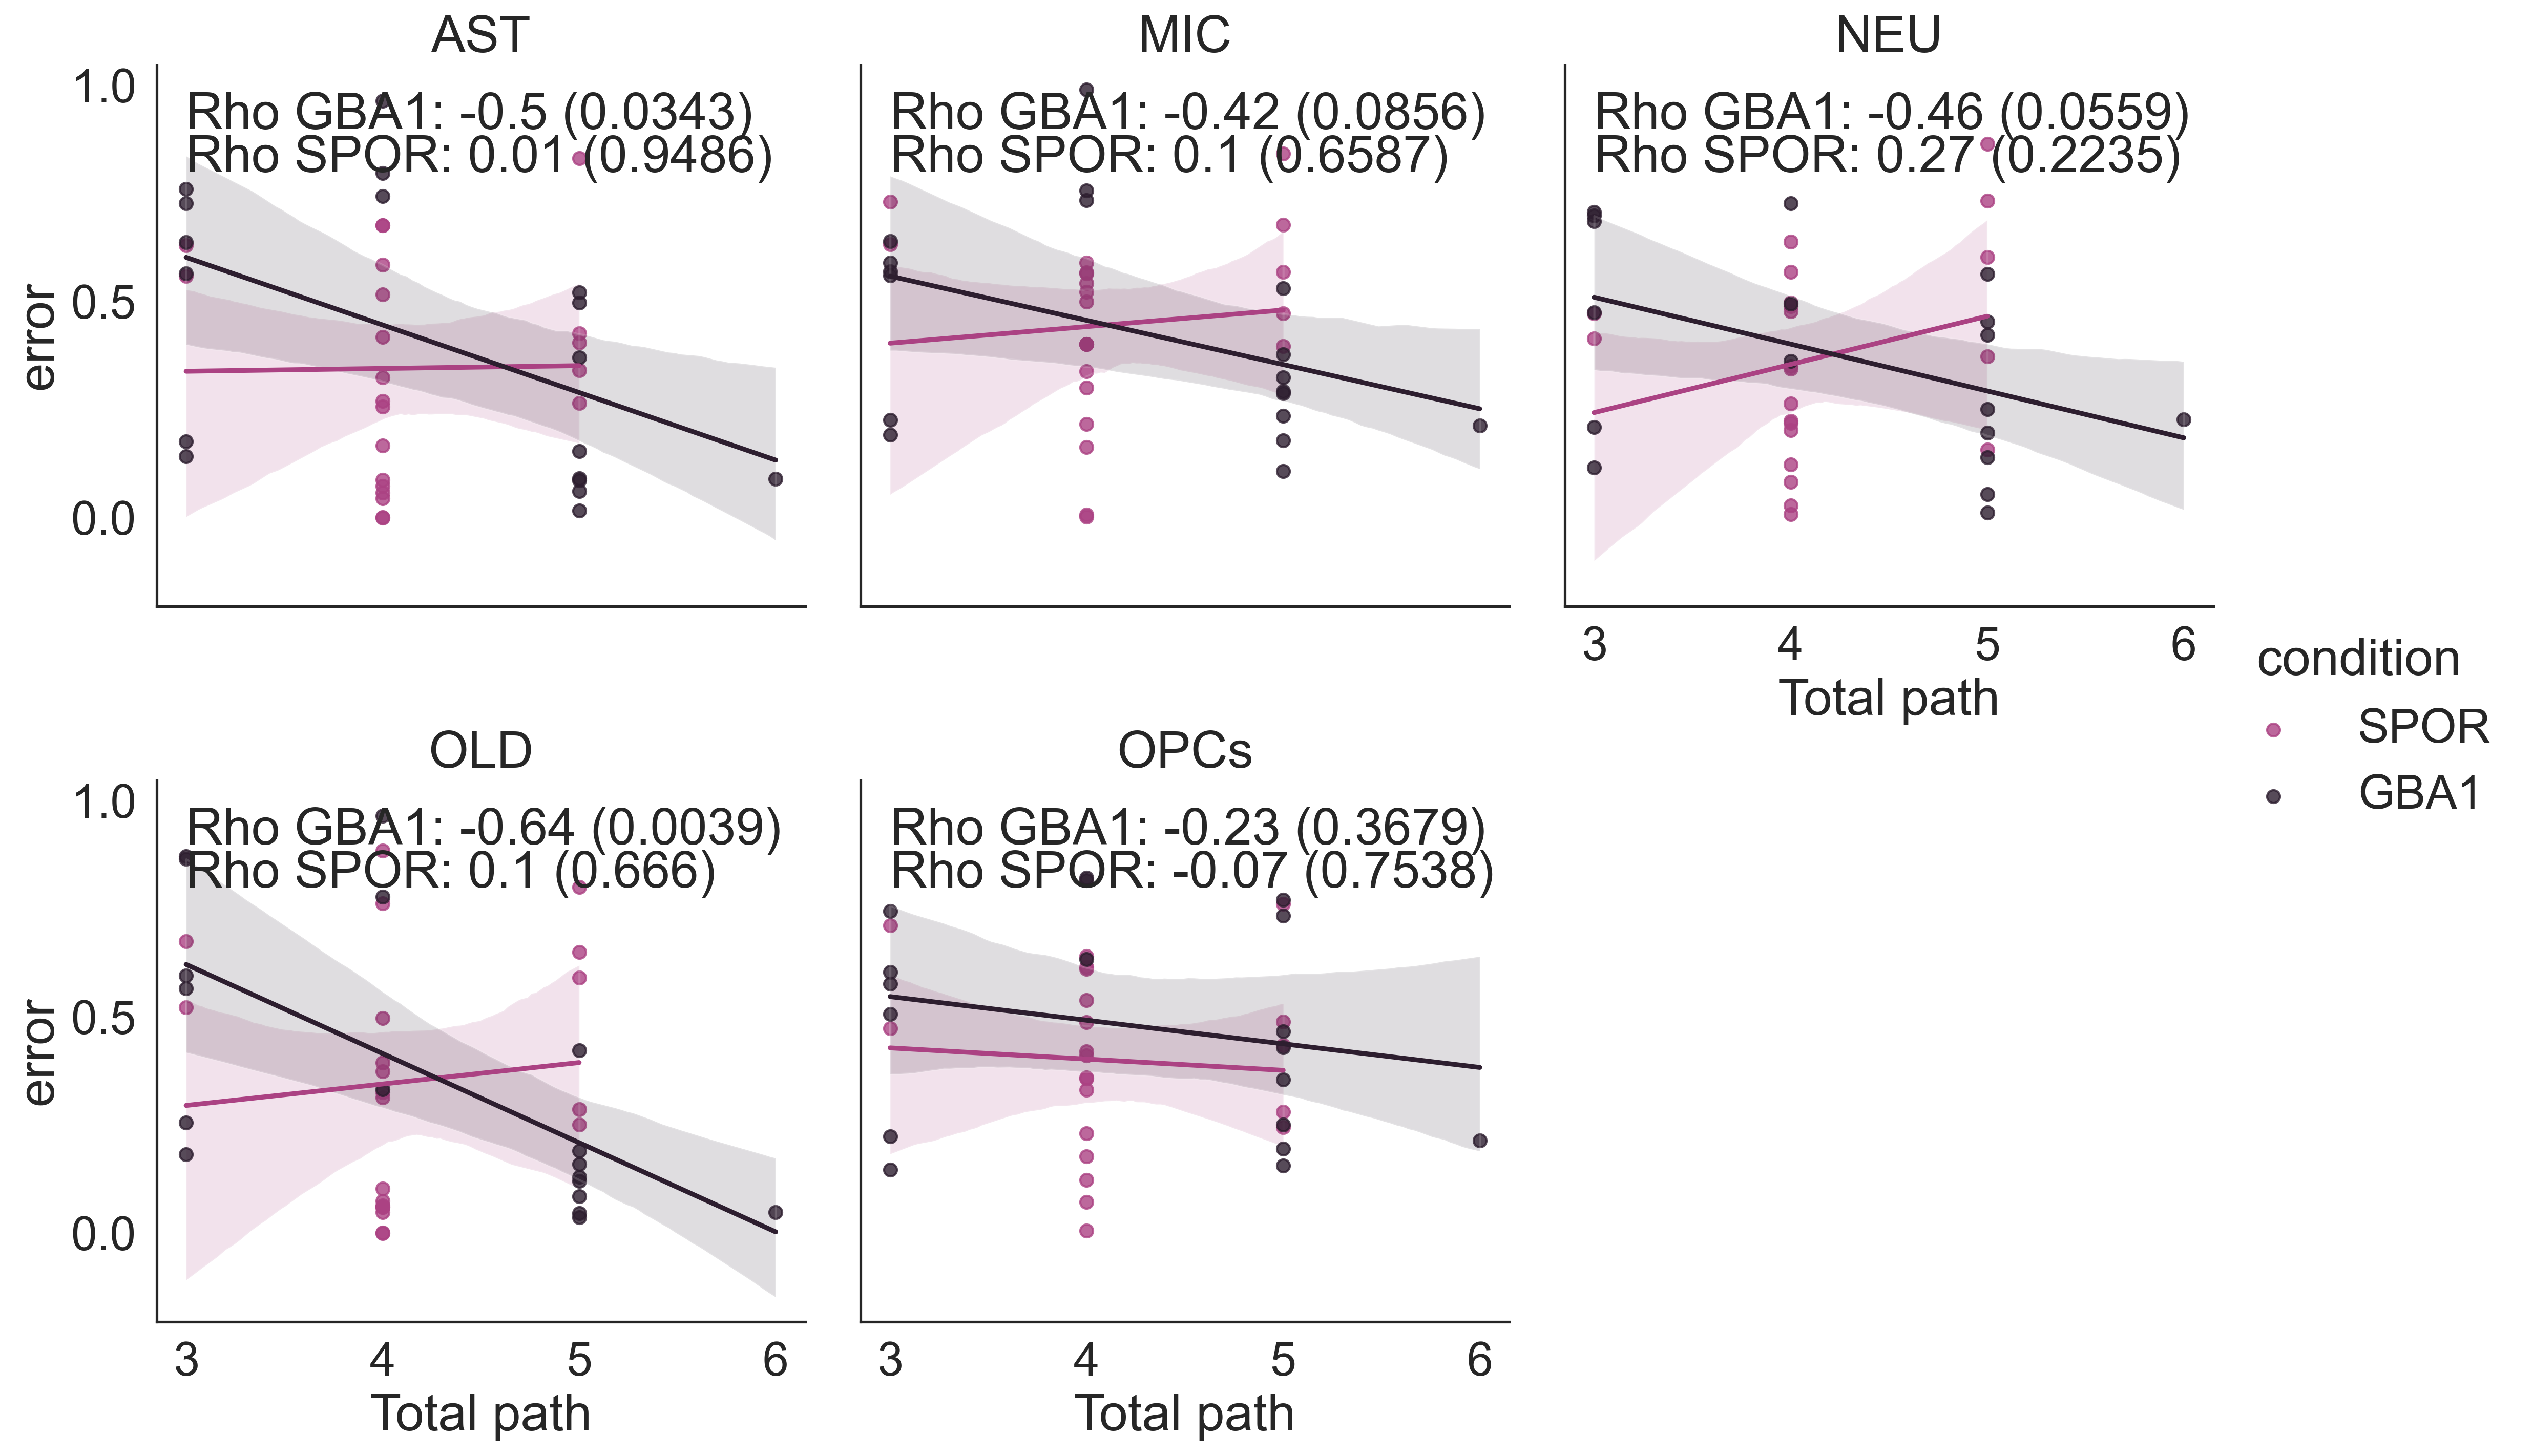

In [179]:
ct = "AST"
all = []
x = "Prediction score"
for ct in celltypes:
    if ct !="bulk":
        dico_ = dico["%s_%s"%(REGION,ct)]
        meta = dico_["meta"].copy()
        meta[x] = dico_["preds"].mean(1).values.astype(float)
        meta["error"] = np.abs(dico_["preds"].mean(1).values.astype(float)-dico_["tests"].mean(1).values.astype(float))
        meta["Cell type"] = ct
        all.append(meta)
all = pd.concat(all)
palette_cov = {"yes":"#003C30","no":"#F6E8C3", "3_4":"#003C30","4_4":"#003C30", "3_3":"#F6E8C3", "2_3":"#F6E8C3","4_2":"#F6E8C3" }


all["ApoE_4"] = all["ApoE_4"].replace({0:"E4-",1:"E4+"})

all[x] = all[x].astype(float)

all["Braak Score"] = all["xxx.Braak score"].map({"I":1, "II":1,"III":2, "IV":2, "V":3, "VI":3}).astype(float).values
all["LB Stages"] = all['xxx.Unified LB Stage'].map({"0. No Lewy bodies":0.,"lV. Neocortical":3.,
                                                     "lll. Brainstem/Limbic":2.,"lla. Brainstem Predominant":1.,
                                                               "llb. Limbic Predominant":2.}).values
all["Total path"] = all["Braak Score"].values.astype(float) + all["LB Stages"].values.astype(float)
all["Total path"] 

palette_cov = {"yes":"#003C30","no":"#F6E8C3","Neocortical LB":"#003C30","Brainstem/Limbic LB":"#F6E8C3", "3_4":"#003C30","4_4":"#003C30", "3_3":"#F6E8C3", "2_3":"#F6E8C3","4_2":"#F6E8C3" }
var = "Neocortical LB"#, "LB_isBrainstem/Limbic"
var="Unified LB Stage"
# var="LB Stages"
all[var] = all[var].map({1:"Neocortical LB", 0:"No LB", 2:"Brainstem/Limbic LB"})
print(all[var].unique())
all = all[~all[var].isna()]
all = all.sort_values([var, "celltype"])
sns.set(style="white", font_scale=2)
# fig, axes = plt.subplots(2,3, figsize=(12,5), sharey=True)
# axes = axes.flatten()
x = "Total path"
y="error"
# for ii, it in enumerate(celltypes):
#     print(it)
#     ax=axes[ii]
if True:
    # tmp = all[all["Cell type"]==it]
    fct = sns.lmplot(data=all, #ax=ax, 
                    x=x,
                    y=y,
                   col_wrap=3,
                    col="Cell type",
                 hue="condition",
                    palette=COLORS_CT#[it]
               )
for ct,it in fct.axes_dict.items():
    print(ct)
    tmp1 = all[(all["Cell type"]==ct) & (all.condition=="SPOR")]
    tmp2 = all[(all["Cell type"]==ct) & (all.condition=="GBA1")]
    xx = tmp1[x]
    yy=tmp1[y]
    r1,p1 = pearsonr(xx,yy)
    xx = tmp2[x]
    yy=tmp2[y]
    r2,p2 = pearsonr(xx,yy)
    it.text(3,0.9, f"Rho GBA1: {np.round(r2,2)} ({np.round(p2,4)})")
    it.text(3,0.8, f"Rho SPOR: {np.round(r1,2)} ({np.round(p1,4)})")
    it.set_title(ct)
    # ax.legend(bbox_to_anchor=(1,1), title=var)
    # pairs=[((ct,"Neocortical LB"),(ct,"Brainstem/Limbic LB"))for ct in all["Cell type"].unique()]
    # pairs=[((ct,"SPOR"),(ct,"GBA1"))for ct in all["Cell type"].unique()]

    # ax.axhline(0.5,c="k", linewidth=0.2)
    # annotator= Annotator(pairs=pairs,data=all[all[var]==it], ax=ax, y=x,x="Cell type", hue="condition")
    # annotator.configure(test='Mann-Whitney', text_format='star',comparisons_correction='holm')
    # annotator.apply_and_annotate()
    ax.set_title(it)
plt.savefig("./outdir/boxplot_prediction_stratified_by_%s_gba1_spor.svg"%x.replace(" ","-"))   
